# C01 - Football Event Intelligence

**Colab-first analytical notebook**

This notebook documents the analysis completed so far for the 2023/24 FA Women’s Super League case. It is designed to remain fully reproducible from the frozen raw StatsBomb JSON while also being practical on modest hardware and temporary Google Colab runtimes.

The workflow separates permanent storage from runtime compute:

- **Google Drive raw JSON** = source of truth;
- **Parquet event cache** = portable, fast reload of the compact analytical event layer;
- **stage checkpoints** = small derived tables saved only after their upstream definitions and reconciliation checks have passed;
- **Colab `/content`** = temporary fast working storage for the current session.

A checkpoint is a development shortcut, not a replacement for the construction code. If an upstream definition changes, force the relevant rebuild and regenerate downstream checkpoints.


## 1. Colab Setup and Season Scope


### 1.1 Runtime, Drive, paths and cache policy


In [ ]:
# Core imports and Colab/Drive setup.
import gc
import json
import shutil
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import pyarrow
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyarrow"])
    import pyarrow

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

# CHANGE ONLY THIS PATH if your Drive folder uses a different name/location.
if IN_COLAB:
  PROJECT_ROOT = Path(
    "/content/drive/My Drive/02 Work & Career/00 Current Work/"
    "Independent Sports Analytics/00 Active Projects/"
    "Analytical Casework Lab/01 - Case Releases/"
    "C01 - Football Event Intelligence")
else:
    PROJECT_ROOT = Path.cwd()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
MATCHES_DIR = RAW_DIR / "matches"
EVENTS_DIR = RAW_DIR / "events"
CACHE_DIR = PROJECT_ROOT / "data" / "cache"
CHECKPOINT_DIR = PROJECT_ROOT / "data" / "checkpoints"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Colab local disk is faster than repeatedly reading a large cache from Drive.
LOCAL_WORK_DIR = Path("/content/c01_work") if IN_COLAB else CACHE_DIR
LOCAL_WORK_DIR.mkdir(parents=True, exist_ok=True)

# Source-of-truth scope.
SOURCE_COMMIT = "b0bc9f22dd77c206ddedc1d742893b3bbe64baec"
COMPETITION_ID = 37
SEASON_ID = 281
CHELSEA_ID = 971
HIGH_REGAIN_X = 80

# Rebuild switches.
# Normal later session: leave both False.
# Set FORCE_REBUILD_EVENTS=True only if the raw data/event-layer schema changes.
# Set FORCE_REBUILD_STAGE8=True if regain/opportunity definitions or upstream logic changes.
FORCE_REBUILD_EVENTS = False
FORCE_REBUILD_STAGE8 = False

# Memory preference: release large temporary audit tables once stage 8 is checkpointed.
RELEASE_UPSTREAM_MEMORY = True

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("pyarrow:", pyarrow.__version__)
print("Project root:", PROJECT_ROOT)
print("Raw events dir:", EVENTS_DIR)
print("Cache dir:", CACHE_DIR)


Mounted at /content/drive
Python: 3.13.15
pandas: 2.2.3
pyarrow: 18.1.0
Project root: /content/drive/My Drive/02 Work & Career/00 Current Work/Independent Sports Analytics/00 Active Projects/Analytical Casework Lab/01 - Case Releases/C01 - Football Event Intelligence
Raw events dir: /content/drive/My Drive/02 Work & Career/00 Current Work/Independent Sports Analytics/00 Active Projects/Analytical Casework Lab/01 - Case Releases/C01 - Football Event Intelligence/data/raw/events
Cache dir: /content/drive/My Drive/02 Work & Career/00 Current Work/Independent Sports Analytics/00 Active Projects/Analytical Casework Lab/01 - Case Releases/C01 - Football Event Intelligence/data/cache


#### Expected Drive layout

Upload the frozen source data once using this layout:

```text
MyDrive/
└── analytical-casework-lab/
    └── data/
        ├── raw/
        │   ├── matches/
        │   │   └── 281.json
        │   └── events/
        │       ├── <match_id>.json
        │       └── ... all 132 match event files
        ├── cache/
        └── checkpoints/
```

The first complete run builds the compact event cache and stage-8 checkpoints. Later Colab sessions reload them automatically. The notebook retains every construction and validation cell for reproducibility, but skips the expensive upstream reconstruction when valid checkpoints already exist.


In [ ]:
# Coordinate helpers that work with raw JSON lists and Arrow/Parquet array-like values.
def is_array_like(value):
    return isinstance(value, (list, tuple, np.ndarray))


def get_coord(value, position):
    if is_array_like(value) and len(value) > position:
        return value[position]
    return np.nan


def get_x(value):
    return get_coord(value, 0)


def get_y(value):
    return get_coord(value, 1)


def copy_to_local(drive_path: Path, local_name: str) -> Path:
    """Copy a persistent Drive file to fast session-local storage when in Colab."""
    if not drive_path.exists():
        raise FileNotFoundError(drive_path)

    if not IN_COLAB:
        return drive_path

    local_path = LOCAL_WORK_DIR / local_name
    shutil.copy2(drive_path, local_path)
    return local_path


def dataframe_memory_mb(df):
    return df.memory_usage(deep=True).sum() / 1024**2


**Why Parquet rather than pickle?** Pickle is Python-specific serialization and can become fragile across environments or library versions. Parquet is an Arrow-based tabular format intended for portable analytical data exchange and fast columnar reads. List-valued StatsBomb coordinate fields may reload as Arrow/NumPy-style arrays rather than Python lists, so all coordinate helpers above deliberately accept both representations.


### 1.2 Define the league match universe and target team


In [ ]:
# Load the frozen season match file and inspect its shape.
matches_path = MATCHES_DIR / f"{SEASON_ID}.json"

if not matches_path.exists():
    raise FileNotFoundError(
        f"Missing season match file: {matches_path}. "
        "Upload the frozen matches file to Drive using the layout above."
    )

with matches_path.open("r", encoding="utf-8") as f:
    matches = json.load(f)

matches_df = pd.json_normalize(matches)
expected_match_ids = matches_df["match_id"].astype(int).tolist()

print("Number of matches:", len(matches_df))
print("Expected event files:", len(expected_match_ids))
print("\nColumns:")
print(matches_df.columns.tolist())


Number of matches: 132
Expected event files: 132

Columns:
['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition.competition_id', 'competition.country_name', 'competition.competition_name', 'season.season_id', 'season.season_name', 'home_team.home_team_id', 'home_team.home_team_name', 'home_team.home_team_gender', 'home_team.home_team_group', 'home_team.country.id', 'home_team.country.name', 'home_team.managers', 'away_team.away_team_id', 'away_team.away_team_name', 'away_team.away_team_gender', 'away_team.away_team_group', 'away_team.country.id', 'away_team.country.name', 'away_team.managers', 'metadata.data_version', 'metadata.shot_fidelity_version', 'metadata.xy_fidelity_version', 'competition_stage.id', 'competition_stage.name', 'stadium.id', 'stadium.name', 'stadium.country.id', 'stadium.country.name', 'referee.id', 'referee.name', 'referee.country.id', 'referee.country.

In [ ]:
# Preview the key match and team fields used to define the season universe.
cols = [
    "match_id",
    "match_date",
    "home_team.home_team_id",
    "home_team.home_team_name",
    "away_team.away_team_id",
    "away_team.away_team_name",
]

matches_df[cols].head()

,match_id,match_date,home_team.home_team_id,home_team.home_team_name,away_team.away_team_id,away_team.away_team_name
0,3913082,2023-11-05,965,Brighton & Hove Albion WFC,1475,Manchester United W
1,3913155,2024-03-23,746,Manchester City WFC,1475,Manchester United W
2,3913167,2024-04-21,1475,Manchester United W,749,Tottenham Hotspur Women
3,3913175,2024-04-28,2647,Aston Villa W,972,West Ham United LFC
4,3913107,2023-12-09,746,Manchester City WFC,2647,Aston Villa W


In [ ]:
# Check: identify the unique teams represented in the season file.
teams = pd.concat([
    matches_df[[
        "home_team.home_team_id",
        "home_team.home_team_name"
    ]].rename(columns={
        "home_team.home_team_id": "team_id",
        "home_team.home_team_name": "team_name"
    }),

    matches_df[[
        "away_team.away_team_id",
        "away_team.away_team_name"
    ]].rename(columns={
        "away_team.away_team_id": "team_id",
        "away_team.away_team_name": "team_name"
    })
]).drop_duplicates().sort_values("team_name")

print("Number of teams:", len(teams))
print(teams.to_string(index=False))

Number of teams: 12
 team_id                  team_name
     968                Arsenal WFC
    2647              Aston Villa W
     965 Brighton & Hove Albion WFC
     973           Bristol City WFC
     971                Chelsea FCW
     967                Everton LFC
    2652         Leicester City WFC
     966              Liverpool WFC
     746        Manchester City WFC
    1475        Manchester United W
     749    Tottenham Hotspur Women
     972        West Ham United LFC


In [ ]:
# Check: verify each team appears the expected number of times across home and away fixtures.
home_apps = (
    matches_df["home_team.home_team_name"]
    .value_counts()
)

away_apps = (
    matches_df["away_team.away_team_name"]
    .value_counts()
)

team_apps = (
    home_apps.add(away_apps, fill_value=0)
    .sort_index()
)

print(team_apps)

Arsenal WFC                   22
Aston Villa W                 22
Brighton & Hove Albion WFC    22
Bristol City WFC              22
Chelsea FCW                   22
Everton LFC                   22
Leicester City WFC            22
Liverpool WFC                 22
Manchester City WFC           22
Manchester United W           22
Tottenham Hotspur Women       22
West Ham United LFC           22
Name: count, dtype: int64


In [ ]:
# Check: confirm Chelsea FCW appears in 22 league matches.
chelsea_matches = matches_df[
    (matches_df["home_team.home_team_id"] == CHELSEA_ID) |
    (matches_df["away_team.away_team_id"] == CHELSEA_ID)
]

print("Chelsea matches:", len(chelsea_matches))
print(
    chelsea_matches[
        [
            "match_id",
            "match_date",
            "home_team.home_team_name",
            "away_team.away_team_name"
        ]
    ].sort_values("match_date").to_string(index=False)
)

Chelsea matches: 22
 match_id match_date   home_team.home_team_name   away_team.away_team_name
  3912597 2023-10-01                Chelsea FCW    Tottenham Hotspur Women
  3912600 2023-10-08        Manchester City WFC                Chelsea FCW
  3913069 2023-10-14                Chelsea FCW        West Ham United LFC
  3913077 2023-10-22                Chelsea FCW Brighton & Hove Albion WFC
  3913081 2023-11-04              Aston Villa W                Chelsea FCW
  3913089 2023-11-12                Everton LFC                Chelsea FCW
  3913093 2023-11-18                Chelsea FCW              Liverpool WFC
  3913103 2023-11-26                Chelsea FCW         Leicester City WFC
  3913105 2023-12-10                Arsenal WFC                Chelsea FCW
  3913112 2023-12-17           Bristol City WFC                Chelsea FCW
  3913121 2024-01-21                Chelsea FCW        Manchester United W
  3913123 2024-01-27 Brighton & Hove Albion WFC                Chelsea FCW
  391

In [ ]:
# Check: confirm the season date range.
matches_df["match_date"] = pd.to_datetime(matches_df["match_date"])

print("First match:", matches_df["match_date"].min())
print("Last match:", matches_df["match_date"].max())

First match: 2023-10-01 00:00:00
Last match: 2024-05-18 00:00:00


**What we did.** Defined the season from the frozen match file, confirmed 132 matches and 12 teams, and verified that Chelsea FCW appears in 22 fixtures.

**Why it matters.** All later event analysis must reconcile to this exact match universe; otherwise team comparisons could be based on incomplete exposure.

**What comes next.** Inspect the shape of a single event file before loading and combining the full season.


### 1.3 Inspect one StatsBomb event file


In [ ]:
# Inspect one raw event JSON before building/loading the season event layer.
sample_match_id = int(matches_df["match_id"].iloc[0])
event_path = EVENTS_DIR / f"{sample_match_id}.json"

if not event_path.exists():
    raise FileNotFoundError(
        f"Missing sample event file: {event_path}. "
        "Upload all frozen event JSON files to Drive first."
    )

with event_path.open("r", encoding="utf-8") as f:
    sample_events = json.load(f)

print("Events in sample match:", len(sample_events))
print("\nTop-level fields:")
print(sample_events[0].keys())


Events in sample match: 3309

Top-level fields:
dict_keys(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type', 'possession', 'possession_team', 'play_pattern', 'team', 'duration', 'tactics'])


In [ ]:
# Flatten the sample event JSON to inspect the event schema.
events_sample_df = pd.json_normalize(sample_events)

print(events_sample_df.shape)
print(events_sample_df.columns.tolist())

(3309, 121)
['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession', 'duration', 'type.id', 'type.name', 'possession_team.id', 'possession_team.name', 'play_pattern.id', 'play_pattern.name', 'team.id', 'team.name', 'tactics.formation', 'tactics.lineup', 'related_events', 'location', 'player.id', 'player.name', 'position.id', 'position.name', 'pass.recipient.id', 'pass.recipient.name', 'pass.length', 'pass.angle', 'pass.height.id', 'pass.height.name', 'pass.end_location', 'pass.type.id', 'pass.type.name', 'pass.body_part.id', 'pass.body_part.name', 'under_pressure', 'carry.end_location', 'dribble.overrun', 'dribble.outcome.id', 'dribble.outcome.name', 'ball_recovery.offensive', 'pass.assisted_shot_id', 'pass.shot_assist', 'duel.type.id', 'duel.type.name', 'shot.statsbomb_xg', 'shot.end_location', 'shot.key_pass_id', 'shot.aerial_won', 'shot.body_part.id', 'shot.body_part.name', 'shot.type.id', 'shot.type.name', 'shot.outcome.id', 'shot.outcome.name', 'shot.technique.id',

In [ ]:
# Check: inspect the distribution of event types in the sample match.
events_sample_df["type.name"].value_counts()

,count
type.name,
Pass,898
Ball Receipt*,848
Carry,691
Pressure,311
Ball Recovery,117
Duel,73
Clearance,58
Goal Keeper,42
Block,40


**What we did.** Opened and normalized one match-level event file to see how StatsBomb represents events and event-specific columns.

**Why it matters.** StatsBomb event data are wide and sparse: many columns only apply to particular event types, so missing values cannot automatically be treated as data errors.

**What comes next.** Load all 132 event files into one season-level event table and reconcile it to the match universe.


## 2. Build or Reload the Compact Season Event Layer


### 2.1 First run from raw JSON; later sessions from portable Parquet cache


In [ ]:
# Columns required by the completed analysis and the current post-regain work.
# Keeping a compact analytical layer materially reduces RAM compared with holding
# all ~143 normalized StatsBomb columns for the full season.
ANALYSIS_EVENT_COLUMNS = [
    "id",
    "match_id",
    "index",
    "period",
    "timestamp",
    "minute",
    "second",
    "type.name",
    "team.id",
    "team.name",
    "player.id",
    "player.name",
    "possession",
    "possession_team.id",
    "possession_team.name",
    "play_pattern.name",
    "location",
    "pass.type.name",
    "pass.outcome.name",
    "pass.end_location",
    "ball_receipt.outcome.name",
    "ball_recovery.offensive",
    "ball_recovery.recovery_failure",
    "interception.outcome.name",
    "duel.type.name",
    "duel.outcome.name",
    "50_50.outcome.name",
    "goalkeeper.type.name",
    "goalkeeper.outcome.name",
    "goalkeeper.end_location",
    "dribble.outcome.name",
    "carry.end_location",
    "shot.statsbomb_xg",
    "shot.end_location",
    "shot.outcome.name",
]

EVENT_CACHE_DRIVE = CACHE_DIR / "c01_events_analysis.parquet"
EVENT_METADATA_DRIVE = CACHE_DIR / "c01_events_analysis_metadata.json"

event_cache_compatible = False
if EVENT_CACHE_DRIVE.exists() and EVENT_METADATA_DRIVE.exists():
    with EVENT_METADATA_DRIVE.open("r", encoding="utf-8") as f:
        existing_event_metadata = json.load(f)

    event_cache_compatible = (
        existing_event_metadata.get("source_commit") == SOURCE_COMMIT
        and existing_event_metadata.get("season_id") == SEASON_ID
        and existing_event_metadata.get("columns") == ANALYSIS_EVENT_COLUMNS
    )

need_event_rebuild = FORCE_REBUILD_EVENTS or not event_cache_compatible

if need_event_rebuild:
    print("Building event layer from frozen raw JSON...")

    missing_files = [
        match_id
        for match_id in expected_match_ids
        if not (EVENTS_DIR / f"{match_id}.json").exists()
    ]

    if missing_files:
        raise FileNotFoundError(
            f"Missing {len(missing_files)} required event files. "
            f"First IDs: {missing_files[:10]}"
        )

    event_frames = []
    full_schema_union = set()

    for match_id in expected_match_ids:
        path = EVENTS_DIR / f"{match_id}.json"

        with path.open("r", encoding="utf-8") as f:
            events = json.load(f)

        match_df = pd.json_normalize(events)
        full_schema_union.update(match_df.columns)
        match_df["match_id"] = int(match_id)

        # Reindex ensures a stable schema even when an event-specific field is
        # absent from one particular match.
        match_df = match_df.reindex(columns=ANALYSIS_EVENT_COLUMNS)
        event_frames.append(match_df)

    events_df = pd.concat(
        event_frames,
        ignore_index=True,
        sort=False
    )

    # Write locally first in Colab, then copy the portable cache to Drive.
    local_event_cache = LOCAL_WORK_DIR / "c01_events_analysis.parquet"
    events_df.to_parquet(
        local_event_cache,
        engine="pyarrow",
        index=False,
        compression="snappy"
    )

    if IN_COLAB:
        shutil.copy2(local_event_cache, EVENT_CACHE_DRIVE)
    elif local_event_cache != EVENT_CACHE_DRIVE:
        shutil.copy2(local_event_cache, EVENT_CACHE_DRIVE)

    metadata = {
        "source_commit": SOURCE_COMMIT,
        "competition_id": COMPETITION_ID,
        "season_id": SEASON_ID,
        "rows": int(len(events_df)),
        "matches": int(events_df["match_id"].nunique()),
        "columns": ANALYSIS_EVENT_COLUMNS,
        "source_union_column_count_with_match_id": int(len(full_schema_union | {"match_id"})),
        "raw_normalized_columns": sorted(full_schema_union),
        "created_utc": datetime.now(timezone.utc).isoformat(),
    }

    with EVENT_METADATA_DRIVE.open("w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    del event_frames, match_df, events, full_schema_union
    gc.collect()

    print("Built and cached:", EVENT_CACHE_DRIVE)

else:
    print("Loading portable event cache from Drive...")
    local_event_cache = copy_to_local(
        EVENT_CACHE_DRIVE,
        "c01_events_analysis.parquet"
    )
    events_df = pd.read_parquet(
        local_event_cache,
        engine="pyarrow"
    )

with EVENT_METADATA_DRIVE.open("r", encoding="utf-8") as f:
    active_event_metadata = json.load(f)

print(
    "Full normalized source-schema columns (including injected match_id):",
    active_event_metadata.get("source_union_column_count_with_match_id")
)
print("Event layer shape:", events_df.shape)
print(f"Approx. DataFrame memory: {dataframe_memory_mb(events_df):,.1f} MB")

sample_location = events_df["location"].dropna().iloc[0]
print("Sample location:", sample_location)
print("Location runtime type:", type(sample_location))

if not is_array_like(sample_location):
    raise TypeError(
        "Location did not survive cache round-trip as an array-like value. "
        "Delete the event cache and rebuild it from the raw JSON."
    )


Loading portable event cache from Drive...
Full normalized source-schema columns (including injected match_id): 143
Event layer shape: (495189, 35)
Approx. DataFrame memory: 530.5 MB
Sample location: [60. 40.]
Location runtime type: <class 'numpy.ndarray'>


### 2.2 Completeness and integrity checks


In [ ]:
# Check: reconcile the number of matches in the event data to the season match file.
print("Matches in event data:", events_df["match_id"].nunique())
print("Expected matches:", matches_df["match_id"].nunique())

Matches in event data: 132
Expected matches: 132


In [ ]:
# Check: identify any season matches with no loaded event file.
missing_event_matches = (set(matches_df['match_id']) - set(events_df['match_id']))
print(missing_event_matches)

set()


In [ ]:
# Check: verify event IDs are unique after concatenation.
print("Total events:", len(events_df))
print("Unique event IDs:", events_df["id"].nunique())
print("Duplicated event IDs:", events_df["id"].duplicated().sum())

Total events: 495189
Unique event IDs: 495189
Duplicated event IDs: 0


In [ ]:
# Check: summarize event-index uniqueness within each match.
index_check = (events_df.groupby('match_id')['index']
.agg(['count','nunique','min','max']))

index_check.head()

,count,nunique,min,max
match_id,,,,
3912592,3401,3401,1,3401
3912593,4007,4007,1,4007
3912594,2994,2994,1,2994
3912595,3182,3182,1,3182
3912596,3812,3812,1,3812


In [ ]:
# Check: confirm there are no duplicated event indexes within matches.
index_check['duplicate_indexes'] = (index_check['count'] - index_check['nunique'])

print(index_check['duplicate_indexes'].value_counts())

duplicate_indexes
0    132
Name: count, dtype: int64


**What we did.** Combined the season event files and checked match coverage, missing match IDs, unique event IDs and within-match event indexes.

**Why it matters.** These checks establish that the analytical event layer reconciles to the frozen season and is not accidentally duplicated or missing matches.

**What comes next.** Audit the event schema, possession fields and spatial fields that will support the regain definition.


### 2.3 Stage-8 checkpoint policy

The completed upstream analysis through high-regain opportunity linkage is expensive enough that it does not need to be rebuilt during every exploratory Colab session. The notebook therefore checks for small, portable Parquet checkpoints after loading the event layer.

- If the checkpoints do not exist, sections 3–8 run normally and save them after validation.
- If they exist, sections 3–8 are skipped during `Run all`, and the validated outputs needed downstream are reloaded.
- Set `FORCE_REBUILD_STAGE8 = True` near the top whenever an upstream definition or construction rule changes.


In [ ]:
STAGE8_FILES = {
    "regains": CHECKPOINT_DIR / "c01_regains.parquet",
    "high_regains": CHECKPOINT_DIR / "c01_high_regains.parquet",
    "opportunity_possessions": CHECKPOINT_DIR / "c01_opportunity_possessions.parquet",
    "opportunities": CHECKPOINT_DIR / "c01_opportunities.parquet",
    "high_regain_links": CHECKPOINT_DIR / "c01_high_regain_links.parquet",
}

STAGE8_METADATA_PATH = CHECKPOINT_DIR / "c01_stage8_metadata.json"

stage8_files_exist = all(path.exists() for path in STAGE8_FILES.values())
stage8_metadata_compatible = False

if stage8_files_exist and STAGE8_METADATA_PATH.exists():
    with STAGE8_METADATA_PATH.open("r", encoding="utf-8") as f:
        existing_stage8_metadata = json.load(f)

    stage8_metadata_compatible = (
        existing_stage8_metadata.get("source_commit") == SOURCE_COMMIT
        and existing_stage8_metadata.get("high_regain_x") == HIGH_REGAIN_X
    )

stage8_checkpoint_ready = stage8_files_exist and stage8_metadata_compatible
FULL_REBUILD_STAGE8 = FORCE_REBUILD_STAGE8 or not stage8_checkpoint_ready

if FULL_REBUILD_STAGE8:
    print("Stage 8 mode: FULL REBUILD")
else:
    print("Stage 8 mode: FAST RESUME")

    regains = pd.read_parquet(STAGE8_FILES["regains"])
    high_regains = pd.read_parquet(STAGE8_FILES["high_regains"])
    opportunity_possessions_v2 = pd.read_parquet(
        STAGE8_FILES["opportunity_possessions"]
    )
    opportunities = pd.read_parquet(STAGE8_FILES["opportunities"])
    high_regain_links = pd.read_parquet(STAGE8_FILES["high_regain_links"])

    # This is inexpensive and needed by the current post-regain work.
    ordered_events = events_df.sort_values(
        ["match_id", "index"]
    ).copy()

    print("Loaded regains:", len(regains))
    print("Loaded high regains:", len(high_regains))
    print("Loaded opportunities:", len(opportunities))
    print(
        "Linked high regains with qualifying opportunity:",
        int(high_regain_links["previous_possession_was_opportunity"].sum())
    )


Stage 8 mode: FAST RESUME
Loaded regains: 9721
Loaded high regains: 799
Loaded opportunities: 13970
Linked high regains with qualifying opportunity: 776


## 3. Understand the Event Data Before Defining Regains

*Rebuild-only audit section.* These cells execute when stage-8 checkpoints are absent or `FORCE_REBUILD_STAGE8=True`. On a normal resume session, the validated downstream tables are loaded instead.


### 3.1 Event types and possession structure


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: count every event type across the season.
    season_event_types = (
        events_df["type.name"]
        .value_counts()
        .rename_axis("event_type")
        .reset_index(name="count")
    )

    print(season_event_types.to_string(index=False))


In [ ]:
if FULL_REBUILD_STAGE8:
    # Check: inspect missingness in possession identifiers and possession-team IDs.
    print("Missing possession:")
    print(events_df["possession"].isna().sum())

    print("\nMissing possession team:")
    print(events_df["possession_team.id"].isna().sum())


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: summarize the number of StatsBomb possessions per match.
    possessions_per_match = (
        events_df.groupby("match_id")["possession"]
        .nunique()
    )

    print(possessions_per_match.describe())


In [ ]:
if FULL_REBUILD_STAGE8:
    # Inspect a short ordered event sequence to see how event actor and possession team can differ.
    sequence_cols = [
        "match_id",
        "index",
        "period",
        "timestamp",
        "team.name",
        "type.name",
        "possession",
        "possession_team.name",
        "location"
    ]

    events_df[
        events_df["match_id"] == matches_df["match_id"].iloc[0]
    ][sequence_cols].head(50)


**What we did.** Reviewed the season event-type population and the StatsBomb possession fields, then inspected an ordered sequence of events.

**Why it matters.** The team performing an event is not always the same as the team credited with the possession. That distinction becomes critical when identifying the exact point at which control changes.

**What comes next.** Inspect spatial coverage and the event-specific fields most relevant to shots, recoveries and interceptions.


### 3.2 Spatial fields and event-specific attributes


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: inspect the observed coordinate range for located events.
    location_events = events_df[
        events_df["location"].notna()
    ].copy()

    location_events["x"] = location_events["location"].apply(get_x)
    location_events["y"] = location_events["location"].apply(get_y)

    print(location_events[["x", "y"]].describe())


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: measure how often each event type carries a location.
    print(
        events_df.groupby("type.name")["location"]
        .apply(lambda x: x.notna().mean())
        .sort_values()
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: inspect shot fields that may later describe attacking danger.
    shots = events_df[
        events_df["type.name"] == "Shot"
    ]

    print("Shots:", len(shots))

    print(
        shots[
            [
                "location",
                "shot.statsbomb_xg",
                "shot.end_location",
                "shot.outcome.name"
            ]
        ].isna().sum()
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: inspect Ball Recovery fields relevant to regain semantics.
    recoveries = events_df[
        events_df["type.name"] == "Ball Recovery"
    ]

    print("Ball Recoveries:", len(recoveries))

    print(
        recoveries[
            [
                "team.id",
                "player.id",
                "location",
                "possession",
                "possession_team.id",
                "ball_recovery.offensive",
                "ball_recovery.recovery_failure"
            ]
        ].isna().sum()
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: inspect Interception fields relevant to regain semantics.
    interceptions = events_df[
        events_df["type.name"] == "Interception"
    ]

    print("Interceptions:", len(interceptions))

    print(
        interceptions[
            [
                "location",
                "interception.outcome.name",
                "possession",
                "possession_team.id"
            ]
        ].isna().sum()
    )


**What we did.** Confirmed an approximately 0–120 by 0–80 location system and inspected the fields available on shots, Ball Recoveries and Interceptions.

**Why it matters.** The data contain enough spatial and possession information to reconstruct regains, but no single event type can safely be assumed to represent every regain.

**What comes next.** Reconstruct literal possession starts and study how possessions change from one team to another.


## 4. Reconstruct Possessions and Team Changes


### 4.1 Validate possession-team consistency


In [ ]:
if FULL_REBUILD_STAGE8:
    # Check: verify each match-possession is assigned to one possession team.
    possession_team_check = (
        events_df
        .groupby(["match_id", "possession"])["possession_team.id"]
        .nunique()
    )

    print(possession_team_check.value_counts())


**What we did.** Verified that each match-specific possession is credited to one unique possession team.

**Why it matters.** This supports using `match_id + possession` as the sequence key for possession-level reconstruction.

**What comes next.** Extract the literal first event of each possession in chronological event-index order.


### 4.2 Literal possession starts and chronological ordering


In [ ]:
if FULL_REBUILD_STAGE8:
    # Build literal possession starts in event-index order and count whether the possession team changes.
    possession_starts_idx = (
        events_df
        .sort_values(["match_id", "index"])
        .drop_duplicates(
            subset=["match_id", "possession"],
            keep="first"
        )
        .sort_values(["match_id", "index"])
        .copy()
    )

    possession_starts_idx["previous_possession_team"] = (
        possession_starts_idx
        .groupby("match_id")["possession_team.id"]
        .shift(1)
    )

    transition_rows_idx = possession_starts_idx[
        possession_starts_idx["previous_possession_team"].notna()
    ].copy()

    transition_rows_idx["team_changed"] = (
        transition_rows_idx["possession_team.id"]
        != transition_rows_idx["previous_possession_team"]
    )

    print(transition_rows_idx["team_changed"].value_counts())


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: inspect which literal event types begin possessions.
    print("Possessions:", len(possession_starts_idx))

    display(
        possession_starts_idx["type.name"]
        .value_counts()
        .rename_axis("first_event_type")
        .reset_index(name="count")
        .head(25)
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Check: confirm possession numbers never move backwards within a match.
    print(
        possession_starts_idx
        .groupby("match_id")["possession"]
        .apply(lambda x: x.is_monotonic_increasing)
        .value_counts()
    )


**What we did.** Used the first literal event row of every possession and confirmed that possession numbers are chronologically monotonic within all matches.

**Why it matters.** A coherent first row is essential: column-wise `groupby().first()` can combine values from different source rows when columns contain missing values.

**What comes next.** Build a richer possession table containing both the first and last event so transitions can be examined from both sides.


### 4.3 Build a two-sided possession-transition table


In [ ]:
if FULL_REBUILD_STAGE8:
    # Build coherent first and last event rows for every possession.
    ordered_events = events_df.sort_values(
        ["match_id", "index"]
    ).copy()

    first_events = (
        ordered_events
        .drop_duplicates(
            ["match_id", "possession"],
            keep="first"
        )
        [[
            "match_id",
            "possession",
            "index",
            "type.name",
            "team.id",
            "team.name",
            "possession_team.id",
            "possession_team.name",
            "location"
        ]]
        .rename(columns={
            "index": "start_index",
            "type.name": "start_event",
            "team.id": "start_event_team_id",
            "team.name": "start_event_team",
            "possession_team.id": "possession_team_id",
            "possession_team.name": "possession_team",
            "location": "start_location"
        })
    )

    last_events = (
        ordered_events
        .drop_duplicates(
            ["match_id", "possession"],
            keep="last"
        )
        [[
            "match_id",
            "possession",
            "index",
            "type.name",
            "team.id",
            "team.name",
            "location"
        ]]
        .rename(columns={
            "index": "end_index",
            "type.name": "end_event",
            "team.id": "end_event_team_id",
            "team.name": "end_event_team",
            "location": "end_location"
        })
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Combine the first and last event rows into one possession-level table.
    possessions = (
        first_events
        .merge(
            last_events,
            on=["match_id", "possession"],
            how="left"
        )
        .sort_values(["match_id", "start_index"])
        .copy()
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Attach the immediately preceding possession context within each match.
    previous_cols = [
        "possession",
        "possession_team_id",
        "possession_team",
        "end_event",
        "end_event_team_id",
        "end_event_team",
        "end_location"
    ]

    for col in previous_cols:
        possessions[f"previous_{col}"] = (
            possessions
            .groupby("match_id")[col]
            .shift(1)
        )

    possessions["team_changed"] = (
        possessions["possession_team_id"]
        != possessions["previous_possession_team_id"]
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Keep only possession rows that have a preceding possession.
    transitions = possessions[
        possessions["previous_possession"].notna()
    ].copy()


In [ ]:
if FULL_REBUILD_STAGE8:
    # Isolate transitions where possession changes from one team to the other.
    team_change_transitions = transitions[
        transitions["team_changed"]
    ].copy()


**What we did.** Built one possession-level table containing how each possession starts, how it ends and which team held the preceding possession.

**Why it matters.** This makes it possible to distinguish simple possession-number changes from actual team changes and to inspect the event context around each turnover.

**What comes next.** Audit how team-change possessions begin, especially the many cases where the new possession starts with a Pass.


### 4.4 Explore how team-change possessions begin


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: inspect previous-end/new-start event combinations for team-change possessions.
    transition_patterns = (
        team_change_transitions
        .groupby(
            ["previous_end_event", "start_event"]
        )
        .size()
        .sort_values(ascending=False)
        .reset_index(name="count")
    )

    print(transition_patterns.head(30).to_string(index=False))


In [ ]:
if FULL_REBUILD_STAGE8:
    # Attach play-pattern and pass-type context to each team-change possession start.
    start_context = (
        ordered_events[
            [
                "match_id",
                "index",
                "play_pattern.name",
                "pass.type.name",
                "pass.outcome.name"
            ]
        ]
        .rename(columns={
            "index": "start_index",
            "play_pattern.name": "start_play_pattern",
            "pass.type.name": "start_pass_type",
            "pass.outcome.name": "start_pass_outcome"
        })
    )

    team_change_context = (
        team_change_transitions
        .merge(
            start_context,
            on=["match_id", "start_index"],
            how="left"
        )
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: inspect play patterns for possession changes that start with a Pass.
    pass_starts = team_change_context[
        team_change_context["start_event"] == "Pass"
    ]

    print(
        pass_starts["start_play_pattern"]
        .value_counts(dropna=False)
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: inspect pass types for possession changes that start with a Pass.
    print(
        pass_starts["start_pass_type"]
        .value_counts(dropna=False)
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Cross-check: compare Pass start type against play pattern.
    pd.crosstab(
        pass_starts["start_play_pattern"],
        pass_starts["start_pass_type"].fillna("<missing>"),
        margins=True
    )


**What we did.** Found that possession-team changes begin through a heterogeneous mix of event types and contexts. Pass starts include both explicit restarts and open-play Recovery/Interception encodings.

**Why it matters.** This demonstrates that neither `Ball Recovery` alone nor `Pass` alone can define a regain. Play pattern and sequence context are needed to separate live-ball gains from restarts.

**What comes next.** Inspect candidate open-play Pass-start gains and manually verify how the possession boundary relates to the ball-winning action.


## 5. Determine What Counts as a Regain


### 5.1 Audit open-play Pass-start possession gains


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: isolate Pass-start gains labelled Recovery or Interception and inspect preceding events.
    candidate_pass_starts = pass_starts[
        pass_starts["start_pass_type"].isin(
            ["Recovery", "Interception"]
        )
    ].copy()

    print(
        candidate_pass_starts
        .groupby(
            ["start_pass_type", "previous_end_event"]
        )
        .size()
        .sort_values(ascending=False)
        .head(25)
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Check: identify which team performed the final event before each candidate Pass-start gain.
    candidate_pass_starts["previous_event_by_old_possession_team"] = (
        candidate_pass_starts["previous_end_event_team_id"]
        == candidate_pass_starts["previous_possession_team_id"]
    )

    candidate_pass_starts["previous_event_by_new_possession_team"] = (
        candidate_pass_starts["previous_end_event_team_id"]
        == candidate_pass_starts["possession_team_id"]
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: summarize preceding event types and their actor-team relationship.
    candidate_pass_starts.groupby(
        [
            "previous_end_event",
            "previous_event_by_old_possession_team",
            "previous_event_by_new_possession_team"
        ]
    ).size().sort_values(ascending=False).head(30)


**What we did.** Isolated Pass-start possession gains labelled Recovery or Interception and compared the preceding event actor with the old and new possession teams.

**Why it matters.** The defensive action that helps win the ball can occur before the formal possession boundary, so the ball-winning mechanism and the reproducible regain anchor are not always the same event.

**What comes next.** Inspect individual sequences around selected possession changes to confirm that interpretation directly in the event order.


### 5.2 Manual sequence validation


In [ ]:
if FULL_REBUILD_STAGE8:
    # Sample: select representative candidate Pass-start transitions for manual inspection.
    examples = candidate_pass_starts[
        candidate_pass_starts["previous_end_event"].isin(
            ["Ball Receipt*", "Pressure", "Block"]
        )
    ].groupby(
        "previous_end_event",
        group_keys=False
    ).head(3)

    display(
        examples[
            [
                "match_id",
                "previous_end_event",
                "previous_end_event_team",
                "previous_possession_team",
                "start_index",
                "start_event",
                "start_event_team",
                "possession_team",
                "start_pass_type"
            ]
        ]
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Validation: inspect nearby events around sampled possession changes.
    for _, row in examples.iterrows():
        match_id = row["match_id"]
        start_index = row["start_index"]

        context = ordered_events[
            (ordered_events["match_id"] == match_id)
            & (ordered_events["index"].between(start_index - 3, start_index + 3))
        ][
            [
                "index",
                "possession",
                "possession_team.name",
                "type.name",
                "team.name",
                "player.name",
                "location",
                "play_pattern.name",
                "pass.type.name"
            ]
        ]

        print(
            "\n",
            match_id,
            row["previous_end_event"],
            "→",
            row["start_pass_type"]
        )

        display(context)


In [ ]:
if FULL_REBUILD_STAGE8:
    # Validation: inspect one Interception-type Pass-start sequence in detail.
    match_id = 3912592
    start_index = 286

    context = ordered_events[
        (ordered_events["match_id"] == match_id)
        & (ordered_events["index"].between(start_index - 4, start_index + 4))
    ][
        [
            "index",
            "possession",
            "possession_team.name",
            "type.name",
            "team.name",
            "player.name",
            "location",
            "play_pattern.name",
            "pass.type.name",
            "pass.outcome.name",
            "ball_receipt.outcome.name",
            "interception.outcome.name"
        ]
    ]

    print(context.to_string(index=False))


In [ ]:
if FULL_REBUILD_STAGE8:
    # Validation: inspect Recovery-type Pass-start sequences in detail.
    for match_id, start_index in [
        (3912592, 1509),
        (3912593, 899)
    ]:
        context = ordered_events[
            (ordered_events["match_id"] == match_id)
            & (ordered_events["index"].between(start_index - 4, start_index + 4))
        ][
            [
                "index",
                "possession",
                "possession_team.name",
                "type.name",
                "team.name",
                "player.name",
                "location",
                "play_pattern.name",
                "pass.type.name",
                "pass.outcome.name",
                "ball_receipt.outcome.name",
                "interception.outcome.name"
            ]
        ]

        print(f"\nMATCH {match_id} - START INDEX {start_index}")
        print(context.to_string(index=False))


**What we did.** Manually inspected event sequences around candidate possession changes, including Recovery- and Interception-type Pass starts.

**Why it matters.** These examples confirmed that preceding pressures, blocks, clearances or other contested actions may occur before the new possession begins. The first event of the new possession is therefore the cleanest reproducible anchor for controlled possession gain.

**What comes next.** Classify the full team-change universe and validate the outcomes of each type of possession start.


### 5.3 Classify and validate the full team-change start universe


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: count the first event type for every team-change possession.
    print(
        team_change_context["start_event"]
        .value_counts()
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Cross-check: compare start event type with start play pattern across all team changes.
    print(
        pd.crosstab(
            team_change_context["start_event"],
            team_change_context["start_play_pattern"],
            margins=True
        ).to_string()
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Schema check: locate event-specific outcome fields needed to validate possession starts.
    for keyword in [
        "ball_recovery",
        "duel.",
        "interception.",
        "goalkeeper.",
        "50/50"
    ]:
        print(f"\n{keyword}")
        print([
            col for col in events_df.columns
            if keyword.lower() in col.lower()
        ])


In [ ]:
if FULL_REBUILD_STAGE8:
    # Schema check: identify the encoded 50/50 outcome field name.
    print([
        col for col in events_df.columns
        if "50" in col.lower()
    ])


In [ ]:
if FULL_REBUILD_STAGE8:
    # Check: verify every team-change start event is performed by the new possession team.
    team_change_context["start_event_by_new_possession_team"] = (
        team_change_context["start_event_team_id"]
        == team_change_context["possession_team_id"]
    )

    print(
        pd.crosstab(
            team_change_context["start_event"],
            team_change_context["start_event_by_new_possession_team"]
        )
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Attach event-specific outcome fields to each team-change possession start.
    start_attributes = (
        ordered_events[
            [
                "match_id",
                "index",
                "ball_recovery.recovery_failure",
                "ball_recovery.offensive",
                "duel.type.name",
                "duel.outcome.name",
                "interception.outcome.name",
                "goalkeeper.type.name",
                "goalkeeper.outcome.name",
                "50_50.outcome.name"
            ]
        ]
        .rename(columns={"index": "start_index"})
    )

    team_change_detail = (
        team_change_context
        .merge(
            start_attributes,
            on=["match_id", "start_index"],
            how="left",
            validate="one_to_one"
        )
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Validation: inspect outcomes for key possession-start event types.
    checks = [
        ("Ball Recovery", "ball_recovery.recovery_failure"),
        ("Duel", "duel.outcome.name"),
        ("Interception", "interception.outcome.name"),
        ("Goal Keeper", "goalkeeper.type.name"),
        ("50/50", "50_50.outcome.name"),
    ]

    for event_type, field in checks:
        subset = team_change_detail[
            team_change_detail["start_event"] == event_type
        ]

        print(f"\n{event_type} - {field}")
        print(subset[field].value_counts(dropna=False))


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: inspect recovery-failure flags across all Ball Recovery events.
    ball_recoveries_all = ordered_events[
        ordered_events["type.name"] == "Ball Recovery"
    ].copy()

    print(
        ball_recoveries_all["ball_recovery.recovery_failure"]
        .value_counts(dropna=False)
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Validation: verify failed Ball Recoveries never serve as team-change starts.
    start_keys = (
        team_change_detail[
            ["match_id", "start_index"]
        ]
        .rename(columns={"start_index": "index"})
        .drop_duplicates()
        .assign(is_team_change_start=True)
    )

    ball_recovery_check = (
        ball_recoveries_all
        .merge(
            start_keys,
            on=["match_id", "index"],
            how="left"
        )
    )

    ball_recovery_check["is_team_change_start"] = (
        ball_recovery_check["is_team_change_start"]
        .fillna(False)
    )

    print(
        pd.crosstab(
            ball_recovery_check[
                "ball_recovery.recovery_failure"
            ].fillna("<missing>"),
            ball_recovery_check["is_team_change_start"]
        )
    )


**What we did.** Validated the full team-change population using start-event actor alignment, play patterns and event-specific outcomes. Failed Ball Recoveries never begin a team-change possession, while candidate Duel, Interception and 50/50 starts show successful outcomes.

**Why it matters.** These checks support using the first event of the new possession as the regain anchor while filtering the context to remove restarts, referee ball-drops and goalkeeper-control possession gains.

**What comes next.** Apply the locked operational regain definition and reconcile the resulting population.


## 6. Operational Regain Definition


### 6.1 Apply the locked definition

**Operational definition:** a regain is a change of possession from one team to the other during live play, anchored at the first event of the new possession. Explicit restarts and referee ball-drops are excluded, as are goalkeeper-control possession gains. The definition measures the observable gain of controlled possession rather than trying to infer which earlier defensive action caused it.


In [ ]:
if FULL_REBUILD_STAGE8:
    # Apply the locked regain definition to the team-change population.
    regains = team_change_detail[
        team_change_detail["start_play_pattern"].isin(
            ["Regular Play", "From Counter"]
        )
        & (team_change_detail["start_event"] != "Goal Keeper")
    ].copy()

    print("Regains:", len(regains))

    print("\nStart events:")
    print(
        regains["start_event"]
        .value_counts()
    )

    print("\nPlay patterns:")
    print(
        regains["start_play_pattern"]
        .value_counts()
    )

    print("\nTeams:")
    print(
        regains["possession_team"]
        .value_counts()
    )


### 6.2 Reconcile the final regain population


In [ ]:
if FULL_REBUILD_STAGE8:
    # Reconciliation checks for the final regain population.
    # Every regain must be performed by the team gaining possession
    print(
        "Start actor mismatches:",
        (
            regains["start_event_team_id"]
            != regains["possession_team_id"]
        ).sum()
    )

    # No goalkeeper starts
    print(
        "Goal Keeper starts:",
        (regains["start_event"] == "Goal Keeper").sum()
    )

    # No excluded restart contexts
    excluded_patterns = [
        "From Throw In",
        "From Goal Kick",
        "From Free Kick",
        "From Kick Off",
        "From Corner",
        "From Keeper",
        "Other",
    ]

    print(
        "Excluded play patterns present:",
        regains["start_play_pattern"]
        .isin(excluded_patterns)
        .sum()
    )


**What we did.** Applied the live-play filter and goalkeeper exclusion to obtain 9,721 regains. The retained starts reconcile by event type and play pattern, and every start event is performed by the new possession team.

**Why it matters.** The regain population is now an explicit, reproducible analytical unit rather than a loose collection of event labels.

**What comes next.** Use event coordinates to establish which direction represents the attacking goal, then define what 'high up the pitch' means.


## 7. Spatial Orientation and the High-Regain Definition


### 7.1 Verify the attacking direction empirically


In [ ]:
if FULL_REBUILD_STAGE8:
    # Validation: use shot locations to confirm that higher x points toward the acting team's attacking goal.
    shots = ordered_events[
        ordered_events["type.name"] == "Shot"
    ].copy()

    shots["shot_x"] = shots["location"].apply(get_x)

    print(shots["shot_x"].describe(
        percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
    ))

    print(
        shots.groupby("team.name")["shot_x"]
        .agg(["count", "min", "median", "max"])
        .sort_values("median")
    )


**What we did.** Examined all shot x-coordinates across the 12 teams; shots cluster close to the high-x end of the pitch.

**Why it matters.** This provides an empirical check in the frozen data that increasing x means moving toward the acting team's attacking goal.

**What comes next.** Inspect where the operational regains occur along the x-axis.


### 7.2 Inspect regain locations


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: inspect the x-coordinate distribution of all operational regains.
    regains["regain_x"] = regains["start_location"].apply(get_x)

    print(
        regains["regain_x"].describe(
            percentiles=[0.05, 0.25, 0.5, 0.75, 0.90, 0.95]
        )
    )


**What we did.** Extracted the x-coordinate of every regain and reviewed its distribution.

**Why it matters.** The distribution shows that very advanced regains are a relatively small subset, so the high-regain threshold should have a clear football interpretation rather than being chosen to favour Chelsea.

**What comes next.** Apply the final-third threshold at x = 80.


### 7.3 Define and describe high regains

The pitch is divided into three equal longitudinal thirds on the 0–120 x-axis. The attacking final third therefore begins at `x = 80`.

**High regain:** an operational regain whose possession-start x-coordinate is `>= 80`.


In [ ]:
if FULL_REBUILD_STAGE8:
    # Apply the final-third threshold (x >= 80) and count high regains.
    HIGH_REGAIN_X = 80

    regains["is_high_regain"] = (
        regains["regain_x"] >= HIGH_REGAIN_X
    )

    high_regains = regains[
        regains["is_high_regain"]
    ].copy()

    print("All regains:", len(regains))
    print("High regains:", len(high_regains))
    print(
        "Share of regains that are high:",
        high_regains.shape[0] / regains.shape[0]
    )

    print("\nHigh regains by team:")
    print(
        high_regains["possession_team"]
        .value_counts()
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Descriptive check: compare raw high-regain counts and each team's high-regain share.
    team_regain_summary = (
        regains
        .groupby("possession_team")
        .agg(
            regains=("is_high_regain", "size"),
            high_regains=("is_high_regain", "sum")
        )
    )

    team_regain_summary["high_regain_share"] = (
        team_regain_summary["high_regains"]
        / team_regain_summary["regains"]
    )

    print(
        team_regain_summary
        .sort_values("high_regains", ascending=False)
    )


**What we did.** Identified 799 high regains, 8.2% of the 9,721-regain population. Chelsea record 94, behind Arsenal (105) and Manchester City (103), and 10.1% of Chelsea's regains occur in the final third.

**Why it matters.** Raw counts and high-regain share describe frequency, but they do not measure opportunity. A team may face more opponent possessions in areas where a high regain is possible.

**What comes next.** Define an exposure denominator based on opponent controlled possession in the opponent's own defensive third.


## 8. Define High-Regain Opportunities and Exposure


### 8.1 Audit what 'controlled possession in the defensive third' looks like

For a team trying to make a high regain, the relevant opponent territory is the opponent's **own defensive third**. Because StatsBomb coordinates are oriented in the acting team's attacking direction, that area is `x <= 40` for the team currently in possession.


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: inspect possession-team actions in the team's own defensive third (x <= 40).
    opponent_control_audit = ordered_events.copy()

    opponent_control_audit["event_x"] = (
        opponent_control_audit["location"].apply(get_x)
    )

    # Only actions performed by the team that StatsBomb credits with the possession.
    possession_team_actions = opponent_control_audit[
        opponent_control_audit["team.id"]
        == opponent_control_audit["possession_team.id"]
    ].copy()

    defensive_third_actions = possession_team_actions[
        possession_team_actions["event_x"] <= 40
    ].copy()

    print(
        defensive_third_actions["type.name"]
        .value_counts()
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Audit: inspect goalkeeper action types occurring in the defensive third.
    print(
        defensive_third_actions[
            defensive_third_actions["type.name"] == "Goal Keeper"
        ]["goalkeeper.type.name"]
        .value_counts(dropna=False)
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Validation: inspect completion/control outcomes for Ball Receipts and goalkeeper actions.
    # Ball Receipt outcome
    print(
        defensive_third_actions[
            defensive_third_actions["type.name"] == "Ball Receipt*"
        ]["ball_receipt.outcome.name"]
        .value_counts(dropna=False)
    )

    # Goalkeeper type x outcome
    print(
        pd.crosstab(
            defensive_third_actions.loc[
                defensive_third_actions["type.name"] == "Goal Keeper",
                "goalkeeper.type.name"
            ],
            defensive_third_actions.loc[
                defensive_third_actions["type.name"] == "Goal Keeper",
                "goalkeeper.outcome.name"
            ],
            dropna=False
        )
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Validation: distinguish completed from incomplete defensive-third dribbles.
    print(
        defensive_third_actions[
            defensive_third_actions["type.name"] == "Dribble"
        ]["dribble.outcome.name"]
        .value_counts(dropna=False)
    )


**What we did.** Audited the event types performed by the possession team in its own defensive third and inspected outcome fields for Ball Receipts, goalkeeper actions and dribbles.

**Why it matters.** Not every defensive-third event proves control: pressures, duels, miscontrols, failed receipts and administrative events can occur there too. The exposure definition therefore uses a conservative set of clear control evidence.

**What comes next.** Create an event-level control flag, then collapse qualifying evidence to one opportunity per opponent possession.


### 8.2 Build the conservative controlled-possession rule

A possession can qualify through clear possession-team evidence in `x <= 40`:

- Pass
- Carry
- completed Ball Receipt
- non-failed Ball Recovery
- selected goalkeeper-control actions (`Collected`, `Keeper Sweeper`, `Smother`)

A completed Dribble is tested as a sensitivity addition rather than being required in the initial rule. Each possession will ultimately count **once**, no matter how many qualifying events it contains.


In [ ]:
if FULL_REBUILD_STAGE8:
    # Build a conservative event-level flag for clear controlled-possession evidence.
    control_actions = ordered_events.copy()

    control_actions["event_x"] = control_actions["location"].apply(get_x)

    # Event must be performed by the possession team
    control_actions = control_actions[
        control_actions["team.id"]
        == control_actions["possession_team.id"]
    ].copy()

    # Own defensive third in the possession team's coordinate frame
    control_actions = control_actions[
        control_actions["event_x"] <= 40
    ].copy()

    basic_control = control_actions["type.name"].isin(
        ["Pass", "Carry"]
    )

    successful_receipt = (
        (control_actions["type.name"] == "Ball Receipt*")
        & (control_actions["ball_receipt.outcome.name"] != "Incomplete")
    )

    successful_recovery = (
        (control_actions["type.name"] == "Ball Recovery")
        & (control_actions["ball_recovery.recovery_failure"] != True)
    )

    keeper_control = (
        (control_actions["type.name"] == "Goal Keeper")
        & control_actions["goalkeeper.type.name"].isin(
            ["Collected", "Keeper Sweeper", "Smother"]
        )
    )

    control_actions["is_control_evidence"] = (
        basic_control
        | successful_receipt
        | successful_recovery
        | keeper_control
    )


### 8.3 Collapse control evidence to one opportunity candidate per possession


In [ ]:
if FULL_REBUILD_STAGE8:
    # Collapse qualifying control evidence to one opportunity candidate per possession.
    opportunity_possessions = (
        control_actions[
            control_actions["is_control_evidence"]
        ]
        [["match_id", "possession", "possession_team.id", "possession_team.name"]]
        .drop_duplicates(["match_id", "possession"])
        .copy()
    )

    print("Qualifying possession opportunities:", len(opportunity_possessions))

    print(
        opportunity_possessions["possession_team.name"]
        .value_counts()
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Sensitivity setup: add completed dribbles as an additional form of control evidence.
    successful_dribble = (
        (control_actions["type.name"] == "Dribble")
        & (control_actions["dribble.outcome.name"] == "Complete")
    )

    control_actions["is_control_evidence_v2"] = (
        control_actions["is_control_evidence"]
        | successful_dribble
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Sensitivity check: test whether completed dribbles add any new qualifying possessions.
    opportunity_possessions_v2 = (
        control_actions.loc[
            control_actions["is_control_evidence_v2"],
            [
                "match_id",
                "possession",
                "possession_team.id",
                "possession_team.name"
            ]
        ]
        .drop_duplicates(["match_id", "possession"])
        .copy()
    )

    print("Original:", len(opportunity_possessions))
    print("With completed dribbles:", len(opportunity_possessions_v2))
    print(
        "Additional possessions:",
        len(opportunity_possessions_v2) - len(opportunity_possessions)
    )


**What we did.** Collapsed clear control events to one row per possession, producing 13,970 qualifying possession candidates. Adding completed dribbles created zero additional qualifying possessions.

**Why it matters.** Counting possessions rather than individual actions prevents a slow build-up with many defensive-third passes from being treated as many separate opportunities.

**What comes next.** Map each qualifying opponent possession to the other team in the match-the team that actually had the opportunity to make a high regain.


### 8.4 Assign each qualifying possession to the defending/opportunity team


In [ ]:
if FULL_REBUILD_STAGE8:
    # Check: verify every match maps to exactly two teams before assigning opportunities.
    match_teams = (
        ordered_events[
            ["match_id", "team.id", "team.name"]
        ]
        .drop_duplicates()
    )

    print(
        match_teams
        .groupby("match_id")
        .size()
        .value_counts()
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Map each qualifying possession to the opposing team that had the high-regain opportunity.
    opportunities = (
        opportunity_possessions_v2
        .merge(
            match_teams,
            on="match_id",
            how="left"
        )
    )

    # Keep the OTHER team in the match
    opportunities = opportunities[
        opportunities["team.id"]
        != opportunities["possession_team.id"]
    ].copy()

    opportunities = opportunities.rename(
        columns={
            "team.id": "opportunity_team_id",
            "team.name": "opportunity_team"
        }
    )

    print("Opportunity rows:", len(opportunities))
    print(
        "Duplicate possession assignments:",
        opportunities.duplicated(
            ["match_id", "possession"]
        ).sum()
    )

    print("\nHigh-regain opportunities faced by each team:")
    print(
        opportunities["opportunity_team"]
        .value_counts()
    )


**What we did.** Mapped every qualifying possession to the opposing team, producing one unique opportunity assignment per possession and zero duplicate assignments. Chelsea face 1,245 qualifying opponent possessions, the highest exposure in the league.

**Why it matters.** This is the denominator needed to compare high-regain frequency fairly across teams with different numbers of relevant opponent build-up possessions.

**What comes next.** Link each high regain to the immediately preceding opponent possession and confirm that the numerator is compatible with the denominator.


### 8.5 Link high regains to their preceding opportunities


In [ ]:
if FULL_REBUILD_STAGE8:
    # Chronology check: map every possession to the possession immediately before it.
    possession_sequence = (
        ordered_events
        .sort_values(["match_id", "index"])
        .drop_duplicates(["match_id", "possession"], keep="first")
        [
            [
                "match_id",
                "possession",
                "index",
                "possession_team.id",
                "possession_team.name"
            ]
        ]
        .copy()
    )

    possession_sequence = possession_sequence.sort_values(
        ["match_id", "index"]
    )

    possession_sequence["previous_possession"] = (
        possession_sequence
        .groupby("match_id")["possession"]
        .shift(1)
    )

    possession_sequence["previous_possession_team_id"] = (
        possession_sequence
        .groupby("match_id")["possession_team.id"]
        .shift(1)
    )

    print(
        "Possession numbers move backwards:",
        (
            possession_sequence
            .groupby("match_id")["possession"]
            .diff()
            .dropna()
            < 0
        ).sum()
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Validation: link every high regain to its chronological preceding possession.
    # Explicit chronological mapping from each possession
    # to the possession immediately before it
    previous_possession_map = (
        possession_sequence[
            [
                "match_id",
                "possession",
                "previous_possession",
                "previous_possession_team_id"
            ]
        ]
        .rename(
            columns={
                "possession": "regain_possession",
                "previous_possession": "previous_possession_chrono",
                "previous_possession_team_id": "previous_team_id_chrono"
            }
        )
        .copy()
    )

    high_regain_links = (
        high_regains
        .merge(
            previous_possession_map,
            left_on=["match_id", "possession"],
            right_on=["match_id", "regain_possession"],
            how="left",
            validate="many_to_one"
        )
    )

    print("High regains:", len(high_regain_links))
    print(
        "Missing previous-possession mappings:",
        high_regain_links["previous_possession_chrono"].isna().sum()
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Reconciliation: test whether each preceding possession qualifies under the opportunity definition.
    opportunity_keys = (
        opportunity_possessions_v2[
            ["match_id", "possession"]
        ]
        .drop_duplicates()
        .rename(
            columns={
                "possession": "previous_possession_chrono"
            }
        )
        .assign(
            previous_possession_was_opportunity=True
        )
    )

    high_regain_links = (
        high_regain_links
        .merge(
            opportunity_keys,
            on=[
                "match_id",
                "previous_possession_chrono"
            ],
            how="left",
            validate="many_to_one"
        )
    )

    high_regain_links[
        "previous_possession_was_opportunity"
    ] = (
        high_regain_links[
            "previous_possession_was_opportunity"
        ]
        .fillna(False)
    )

    print(
        high_regain_links[
            "previous_possession_was_opportunity"
        ].value_counts()
    )

    print("\nBy team:")
    print(
        pd.crosstab(
            high_regain_links["possession_team"],
            high_regain_links[
                "previous_possession_was_opportunity"
            ]
        )
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Check: confirm a high regain never follows possession by the same team.
    print(
        "Previous team equals regain team:",
        (
            high_regain_links["previous_team_id_chrono"]
            == high_regain_links["possession_team_id"]
        ).sum()
    )


**What we did.** Linked all 799 high regains to their chronological preceding possession. There are no missing mappings and no cases where the preceding possession belongs to the same team. Of the 799 high regains, 776 follow a qualifying opportunity; all 94 Chelsea high regains do.

**Why it matters.** The exposure-adjusted numerator should only count high regains arising from possessions included in the opportunity denominator. Chelsea's numerator reconciles perfectly to the proposed exposure universe.

**What comes next.** Inspect the 23 league-wide unmatched cases to ensure they are genuine consequences of the conservative definition rather than obvious missed control situations.


### 8.6 Audit the 23 unmatched league high regains


In [ ]:
if FULL_REBUILD_STAGE8:
    # Exception audit: inspect high regains whose preceding possession did not qualify.
    false_links = high_regain_links.loc[
        high_regain_links["previous_possession_was_opportunity"] == False
    ].copy()

    false_previous_keys = (
        false_links[
            ["match_id", "previous_possession_chrono"]
        ]
        .drop_duplicates()
        .rename(
            columns={
                "previous_possession_chrono": "possession"
            }
        )
    )

    false_previous_events = (
        ordered_events
        .merge(
            false_previous_keys,
            on=["match_id", "possession"],
            how="inner"
        )
        .copy()
    )

    false_previous_events["event_x"] = (
        false_previous_events["location"].apply(get_x)
    )

    # Only actions by the team credited with that possession
    false_previous_team_actions = false_previous_events[
        false_previous_events["team.id"]
        == false_previous_events["possession_team.id"]
    ].copy()

    print("Event types in the 23 previous possessions:")
    print(
        false_previous_team_actions["type.name"]
        .value_counts()
    )

    print("\nDefensive-third event types only:")
    print(
        false_previous_team_actions[
            false_previous_team_actions["event_x"] <= 40
        ]["type.name"]
        .value_counts()
    )

    print("\nPrevious-possession minimum x:")
    print(
        false_previous_team_actions
        .groupby(["match_id", "possession"])["event_x"]
        .min()
        .describe()
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Exception check: verify defensive-third Ball Receipt exceptions are explicitly incomplete.
    receipt_exceptions = false_previous_team_actions.loc[
        (false_previous_team_actions["event_x"] <= 40)
        & (false_previous_team_actions["type.name"] == "Ball Receipt*"),
        [
            "match_id",
            "possession",
            "index",
            "event_x",
            "ball_receipt.outcome.name"
        ]
    ]

    print(receipt_exceptions)
    print(
        receipt_exceptions["ball_receipt.outcome.name"]
        .value_counts(dropna=False)
    )


In [ ]:
if FULL_REBUILD_STAGE8:
    # Exception check: inspect the small set of borderline Dispossessed/Error cases.
    borderline_exceptions = false_previous_team_actions.loc[
        (false_previous_team_actions["event_x"] <= 40)
        & false_previous_team_actions["type.name"].isin(
            ["Dispossessed", "Error"]
        ),
        [
            "match_id",
            "possession",
            "index",
            "possession_team.name",
            "type.name",
            "event_x"
        ]
    ]

    print(borderline_exceptions)


In [ ]:
if FULL_REBUILD_STAGE8:
    # Exception summary: separate possessions that entered x <= 40 from those that never did.
    exception_min_x = (
        false_previous_team_actions
        .groupby(["match_id", "possession"])["event_x"]
        .min()
    )

    print("Exceptions with any possession-team action at x <= 40:",
          (exception_min_x <= 40).sum())

    print("Exceptions with no possession-team action at x <= 40:",
          (exception_min_x > 40).sum())


#### Opportunity definition reached

**What we did.** Audited the 23 unmatched preceding possessions. Five defensive-third Ball Receipts are explicitly incomplete; eight possessions contain no possession-team action at all in `x <= 40`; the remaining defensive-third evidence is dominated by deliberately excluded or ambiguous event types such as referee ball-drops, pressure, two `Dispossessed` events and one `Error`.

**Why it matters.** The unmatched cases are small and mostly consistent with the conservative rule rather than indicating a broken linkage. Broadening the primary definition after observing results could amount to tuning the denominator, so borderline event types are better reserved for sensitivity analysis.

**Locked primary opportunity definition.** One high-regain opportunity is one opponent possession in which the opponent demonstrates controlled possession in its own defensive third (`x <= 40`). Clear control is represented by passes, carries, completed Ball Receipts, non-failed Ball Recoveries and selected goalkeeper-control actions; completed dribbles are harmless to include because they add no new possessions. Each qualifying possession counts once.

**Current reconciliation.**
- 13,970 qualifying opportunity possessions league-wide.
- 1,245 opportunities faced by Chelsea FCW.
- 776 of 799 league high regains (97.1%) follow a qualifying opportunity.
- 94 of 94 Chelsea high regains follow a qualifying opportunity.
- 23 league high regains fall outside the conservative opportunity definition.

**What comes next.** Use the qualifying opportunity denominator and opportunity-linked high-regain numerator for the exposure-adjusted peer comparison, then assess uncertainty and sensitivity before drawing a distinctiveness conclusion.


### 8.7 Persist the validated stage-8 analytical layer

Only after the preceding construction and reconciliation checks succeed do we persist small downstream tables. This is the point that makes later Colab sessions cheap: the full methodology remains above, while normal exploratory work can resume from validated analytical units.


In [ ]:
if FULL_REBUILD_STAGE8:
    regains.to_parquet(
        STAGE8_FILES["regains"],
        engine="pyarrow",
        index=False
    )
    high_regains.to_parquet(
        STAGE8_FILES["high_regains"],
        engine="pyarrow",
        index=False
    )
    opportunity_possessions_v2.to_parquet(
        STAGE8_FILES["opportunity_possessions"],
        engine="pyarrow",
        index=False
    )
    opportunities.to_parquet(
        STAGE8_FILES["opportunities"],
        engine="pyarrow",
        index=False
    )
    high_regain_links.to_parquet(
        STAGE8_FILES["high_regain_links"],
        engine="pyarrow",
        index=False
    )

    stage8_metadata = {
        "source_commit": SOURCE_COMMIT,
        "high_regain_x": HIGH_REGAIN_X,
        "regains": int(len(regains)),
        "high_regains": int(len(high_regains)),
        "opportunity_possessions": int(len(opportunity_possessions_v2)),
        "opportunity_rows": int(len(opportunities)),
        "linked_high_regains": int(
            high_regain_links["previous_possession_was_opportunity"].sum()
        ),
        "created_utc": datetime.now(timezone.utc).isoformat(),
    }

    with STAGE8_METADATA_PATH.open(
        "w", encoding="utf-8"
    ) as f:
        json.dump(stage8_metadata, f, indent=2)

    print("Saved validated stage-8 checkpoints to:", CHECKPOINT_DIR)
else:
    print("Stage-8 checkpoints already loaded; no rebuild/save required.")


Stage-8 checkpoints already loaded; no rebuild/save required.


In [ ]:
# Release large upstream audit tables that are no longer needed for the current stage.
# Keep the event layer, ordered events, regains/high_regains and validated opportunity outputs.
if RELEASE_UPSTREAM_MEMORY:
    removable = [
        "events_sample_df",
        "location_events",
        "season_event_types",
        "possession_starts_idx",
        "transition_rows_idx",
        "first_events",
        "last_events",
        "possessions",
        "transitions",
        "team_change_transitions",
        "transition_patterns",
        "start_context",
        "team_change_context",
        "pass_starts",
        "candidate_pass_starts",
        "examples",
        "start_attributes",
        "team_change_detail",
        "ball_recoveries_all",
        "ball_recovery_check",
        "opponent_control_audit",
        "possession_team_actions",
        "defensive_third_actions",
        "control_actions",
        "opportunity_possessions",
        "false_previous_events",
        "false_previous_team_actions",
    ]

    released = 0
    for name in removable:
        if name in globals():
            del globals()[name]
            released += 1

    gc.collect()
    print(f"Released {released} temporary upstream objects.")
    print(f"events_df memory: {dataframe_memory_mb(events_df):,.1f} MB")


Released 1 temporary upstream objects.
events_df memory: 530.5 MB


## 9. Post-High-Regain Attacking Sequences

The frequency stage is now complete. The next question is what happens **after** a high regain.

The analytical sequence is kept explicit:

```text
High regain
    ↓
Did an attack develop?
    ↓
If yes, how dangerous was it?
```

At this stage, the notebook is still auditing candidate signals. A shot is not automatically treated as the definition of an attack, and an arbitrary time window is not selected in advance.


### 9.1 Reconstruct the possession following every high regain


In [ ]:
# Build one key per high regain, then reconstruct the full possession sequence.
high_regain_keys = (
    high_regains[
        [
            "match_id",
            "possession",
            "start_index",
            "possession_team"
        ]
    ]
    .rename(
        columns={
            "start_index": "regain_index",
            "possession_team": "regain_team"
        }
    )
    .drop_duplicates(["match_id", "possession"])
    .copy()
)

high_regain_sequences = (
    ordered_events
    .merge(
        high_regain_keys,
        on=["match_id", "possession"],
        how="inner",
        validate="many_to_one"
    )
    .sort_values(["match_id", "possession", "index"])
    .copy()
)

print("High regains:", len(high_regain_keys))
print(
    "Reconstructed high-regain possessions:",
    high_regain_sequences[["match_id", "possession"]]
    .drop_duplicates()
    .shape[0]
)
print("Events in those possessions:", len(high_regain_sequences))


High regains: 799
Reconstructed high-regain possessions: 799
Events in those possessions: 18996


**Expected reconciliation:** the first two counts should both be **799**. Every high regain should map to exactly one possession sequence.


### 9.2 Possession duration, event mix and shot occurrence


In [ ]:
# Create elapsed match time in seconds and measure time from the regain anchor.
high_regain_sequences["event_time_seconds"] = (
    high_regain_sequences["minute"] * 60
    + high_regain_sequences["second"]
)

regain_times = (
    high_regain_sequences
    .groupby(["match_id", "possession"])["event_time_seconds"]
    .min()
    .rename("regain_time_seconds")
)

high_regain_sequences = high_regain_sequences.merge(
    regain_times,
    on=["match_id", "possession"],
    how="left",
    validate="many_to_one"
)

high_regain_sequences["seconds_from_regain"] = (
    high_regain_sequences["event_time_seconds"]
    - high_regain_sequences["regain_time_seconds"]
)

sequence_summary = (
    high_regain_sequences
    .groupby(["match_id", "possession", "regain_team"])
    .agg(
        events=("index", "size"),
        duration_seconds=("seconds_from_regain", "max")
    )
    .reset_index()
)

print(
    sequence_summary[["events", "duration_seconds"]]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
)


           events  duration_seconds
count  799.000000        799.000000
mean    23.774718         22.588235
std     21.856718         31.638060
min      2.000000          0.000000
25%     10.000000          7.000000
50%     17.000000         13.000000
75%     31.500000         30.000000
90%     50.000000         49.000000
95%     60.200000         64.000000
max    205.000000        486.000000


In [ ]:
# Audit event types inside the StatsBomb possessions that begin with high regains.
print(
    high_regain_sequences["type.name"]
    .value_counts()
)


type.name
Pass                4685
Ball Receipt*       4514
Carry               4413
Pressure            1991
Ball Recovery        824
Duel                 391
Block                304
Shot                 286
Goal Keeper          268
Clearance            256
Dribble              190
Dispossessed         152
Interception         146
Miscontrol           129
Dribbled Past        116
Foul Committed        85
Foul Won              81
50/50                 35
Injury Stoppage       35
Substitution          29
Tactical Shift        16
Error                 12
Shield                 9
Player On              8
Half End               4
Bad Behaviour          4
Player Off             4
Half Start             4
Offside                3
Own Goal For           1
Own Goal Against       1
Name: count, dtype: int64


In [ ]:
# Descriptive only: identify possessions that contain at least one shot.
shot_by_possession = (
    high_regain_sequences
    .assign(
        contains_shot=(high_regain_sequences["type.name"] == "Shot")
    )
    .groupby(["match_id", "possession", "regain_team"])["contains_shot"]
    .any()
    .reset_index()
)

print(shot_by_possession["contains_shot"].value_counts())
print("\nShot-containing high-regain possessions by team:")
print(
    shot_by_possession[
        shot_by_possession["contains_shot"]
    ]["regain_team"].value_counts()
)


contains_shot
False    547
True     252
Name: count, dtype: int64

Shot-containing high-regain possessions by team:
regain_team
Manchester City WFC           35
Arsenal WFC                   34
Manchester United W           28
Chelsea FCW                   28
Tottenham Hotspur Women       24
Liverpool WFC                 17
Leicester City WFC            17
Everton LFC                   17
Brighton & Hove Albion WFC    16
West Ham United LFC           14
Aston Villa W                 14
Bristol City WFC               8
Name: count, dtype: int64


In [ ]:
# Audit the final recorded event of each high-regain possession.
high_regain_end_events = (
    high_regain_sequences
    .sort_values(["match_id", "possession", "index"])
    .drop_duplicates(["match_id", "possession"], keep="last")
)

print(
    high_regain_end_events["type.name"]
    .value_counts()
)


type.name
Ball Receipt*       160
Goal Keeper         150
Block                66
Clearance            66
Foul Won             55
Pass                 42
Duel                 40
Pressure             36
Dispossessed         30
Miscontrol           30
Shot                 24
Interception         16
Injury Stoppage      15
Tactical Shift       13
Dribble              11
Substitution         11
Shield                7
Ball Recovery         7
Bad Behaviour         4
Player Off            4
Foul Committed        4
Player On             3
Offside               2
Half Start            1
Own Goal Against      1
Carry                 1
Name: count, dtype: int64


The duration audit is deliberately descriptive. StatsBomb possession identifiers can remain active through later phases or stoppages, so the full possession is **not** automatically interpreted as the immediate post-regain attack.


### 9.3 First-shot timing and time-window sensitivity


In [ ]:
# Confirm that shots inside these possessions are taken by the team that made the regain.
high_regain_shots = high_regain_sequences[
    high_regain_sequences["type.name"] == "Shot"
].copy()

print("Shots:", len(high_regain_shots))
print("\nShot actor matches regain team:")
print(
    (
        high_regain_shots["team.name"]
        == high_regain_shots["regain_team"]
    ).value_counts()
)


Shots: 286

Shot actor matches regain team:
True    286
Name: count, dtype: int64


In [ ]:
# Measure time to the first shot in each shot-containing high-regain possession.
first_shot = (
    high_regain_shots
    .groupby(["match_id", "possession", "regain_team"])["seconds_from_regain"]
    .min()
    .rename("seconds_to_first_shot")
    .reset_index()
)

print(
    first_shot["seconds_to_first_shot"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
)

first_shot["shot_time_band"] = pd.cut(
    first_shot["seconds_to_first_shot"],
    bins=[-0.01, 5, 10, 15, 20, 30, float("inf")],
    labels=[
        "0–5 sec",
        "6–10 sec",
        "11–15 sec",
        "16–20 sec",
        "21–30 sec",
        "31+ sec"
    ]
)

print("\nFirst-shot timing bands:")
print(
    first_shot["shot_time_band"]
    .value_counts()
    .sort_index()
)


count    252.000000
mean      13.301587
std       19.489611
min        0.000000
25%        4.000000
50%        7.000000
75%       14.000000
90%       32.900000
95%       44.450000
max      171.000000
Name: seconds_to_first_shot, dtype: float64

First-shot timing bands:
shot_time_band
0–5 sec      100
6–10 sec      62
11–15 sec     35
16–20 sec     15
21–30 sec     12
31+ sec       28
Name: count, dtype: int64


In [ ]:
# Inspect extreme possession durations to distinguish football action from long/stoppage-contaminated possession IDs.
longest_sequences = (
    sequence_summary
    .sort_values("duration_seconds", ascending=False)
    .head(10)
)

display(longest_sequences)

longest_keys = longest_sequences[["match_id", "possession"]].head(3)

longest_events = (
    high_regain_sequences
    .merge(
        longest_keys,
        on=["match_id", "possession"],
        how="inner"
    )[
        [
            "match_id",
            "possession",
            "index",
            "seconds_from_regain",
            "team.name",
            "regain_team",
            "type.name",
            "location"
        ]
    ]
)

display(longest_events)


,match_id,possession,regain_team,events,duration_seconds
312,3913104,86,Manchester United W,31,486
402,3913120,12,Manchester City WFC,203,295
78,3913071,14,Manchester United W,72,263
763,3913182,98,Aston Villa W,19,192
638,3913160,136,Arsenal WFC,205,191
146,3913080,148,West Ham United LFC,37,155
208,3913089,142,Chelsea FCW,52,145
519,3913142,39,Arsenal WFC,155,141
584,3913152,25,Arsenal WFC,133,141
207,3913089,126,Chelsea FCW,90,128


,match_id,possession,index,seconds_from_regain,team.name,regain_team,type.name,location
0,3913071,14,182,0,Manchester United W,Manchester United W,Ball Recovery,"[82.0, 78.5]"
1,3913071,14,183,0,Manchester United W,Manchester United W,Carry,"[82.0, 78.5]"
2,3913071,14,184,3,Manchester United W,Manchester United W,Pass,"[83.4, 68.1]"
3,3913071,14,185,4,Manchester United W,Manchester United W,Ball Receipt*,"[75.7, 64.0]"
4,3913071,14,186,4,Manchester United W,Manchester United W,Pass,"[75.7, 64.0]"
...,...,...,...,...,...,...,...,...
301,3913120,12,392,167,Manchester City WFC,Manchester City WFC,Ball Receipt*,"[64.1, 23.8]"
302,3913120,12,393,167,Manchester City WFC,Manchester City WFC,Duel,"[64.4, 24.4]"
303,3913120,12,394,167,Liverpool WFC,Manchester City WFC,Clearance,"[55.7, 55.7]"
304,3913120,12,395,186,Liverpool WFC,Manchester City WFC,Injury Stoppage,None


In [ ]:
# One row per high regain with first-shot timing attached.
post_regain_summary = (
    high_regain_keys[["match_id", "possession", "regain_team"]]
    .merge(
        first_shot[["match_id", "possession", "seconds_to_first_shot"]],
        on=["match_id", "possession"],
        how="left",
        validate="one_to_one"
    )
)

print("Rows:", len(post_regain_summary))
print(
    "Possessions with any shot:",
    post_regain_summary["seconds_to_first_shot"].notna().sum()
)

SHOT_WINDOWS = [5, 10, 15, 20, 30]

for seconds in SHOT_WINDOWS:
    post_regain_summary[f"shot_within_{seconds}s"] = (
        post_regain_summary["seconds_to_first_shot"].le(seconds)
        & post_regain_summary["seconds_to_first_shot"].notna()
    )

print("\nLeague-wide sensitivity:")
for seconds in SHOT_WINDOWS:
    n = post_regain_summary[f"shot_within_{seconds}s"].sum()
    print(
        f"{seconds:>2}s: {n:>3} / {len(post_regain_summary)} "
        f"({n / len(post_regain_summary):.1%})"
    )


Rows: 799
Possessions with any shot: 252

League-wide sensitivity:
 5s: 100 / 799 (12.5%)
10s: 162 / 799 (20.3%)
15s: 197 / 799 (24.7%)
20s: 212 / 799 (26.5%)
30s: 224 / 799 (28.0%)


In [ ]:
# Compare shot timing sensitivity across teams.
team_shot_sensitivity = (
    post_regain_summary
    .groupby("regain_team")
    .agg(
        high_regains=("possession", "size"),
        **{
            f"shots_{seconds}s": (f"shot_within_{seconds}s", "sum")
            for seconds in SHOT_WINDOWS
        }
    )
)

for seconds in SHOT_WINDOWS:
    team_shot_sensitivity[f"rate_{seconds}s"] = (
        team_shot_sensitivity[f"shots_{seconds}s"]
        / team_shot_sensitivity["high_regains"]
    )

display(
    team_shot_sensitivity[
        [
            "high_regains",
            "rate_5s",
            "rate_10s",
            "rate_15s",
            "rate_20s",
            "rate_30s"
        ]
    ]
    .sort_values("rate_15s", ascending=False)
)


,high_regains,rate_5s,rate_10s,rate_15s,rate_20s,rate_30s
regain_team,,,,,,
Liverpool WFC,50,0.160000,0.280000,0.300000,0.340000,0.340000
Tottenham Hotspur Women,52,0.153846,0.269231,0.288462,0.346154,0.365385
Everton LFC,50,0.120000,0.260000,0.280000,0.280000,0.300000
Leicester City WFC,53,0.188679,0.245283,0.264151,0.283019,0.283019
Manchester City WFC,103,0.106796,0.194175,0.262136,0.281553,0.310680
Manchester United W,93,0.129032,0.172043,0.258065,0.268817,0.290323
West Ham United LFC,51,0.176471,0.215686,0.254902,0.274510,0.274510
Arsenal WFC,105,0.133333,0.200000,0.238095,0.247619,0.266667
Chelsea FCW,94,0.106383,0.170213,0.234043,0.244681,0.265957


**Interpretation boundary.** This sensitivity table describes how often a high regain is followed by a shot under several plausible time horizons. It is not yet the definition of a post-regain attack. The next audit asks whether the regain produces meaningful territorial penetration even when no shot follows.


### 9.4 Subsequent penalty-area activity


In [ ]:
# Analyse subsequent actions by the team that made the high regain.
# Exclude the regain anchor itself because we want to measure what happens after possession is won.
post_regain_team_events = high_regain_sequences[
    (high_regain_sequences["index"] > high_regain_sequences["regain_index"])
    & (
        high_regain_sequences["team.name"]
        == high_regain_sequences["regain_team"]
    )
].copy()

print("Subsequent regain-team events:", len(post_regain_team_events))

post_regain_team_events["event_x"] = (
    post_regain_team_events["location"].apply(get_x)
)
post_regain_team_events["event_y"] = (
    post_regain_team_events["location"].apply(get_y)
)


Subsequent regain-team events: 14307


In [ ]:
# Candidate StatsBomb penalty-area geometry on a 120 x 80 pitch.
BOX_X = 102
BOX_Y_MIN = 18
BOX_Y_MAX = 62

post_regain_team_events["in_penalty_area"] = (
    (post_regain_team_events["event_x"] >= BOX_X)
    & post_regain_team_events["event_y"].between(BOX_Y_MIN, BOX_Y_MAX)
)

box_events = post_regain_team_events[
    post_regain_team_events["in_penalty_area"]
].copy()

print("Subsequent events in penalty area:", len(box_events))
print("\nEvent types:")
print(box_events["type.name"].value_counts())


Subsequent events in penalty area: 1428

Event types:
type.name
Ball Receipt*     484
Carry             258
Pass              236
Shot              181
Pressure           73
Ball Recovery      70
Dribble            29
Miscontrol         26
Dispossessed       23
Duel               22
Block              15
Interception        2
Dribbled Past       2
50/50               2
Foul Committed      2
Own Goal For        1
Offside             1
Foul Won            1
Name: count, dtype: int64


In [ ]:
# Time to the first subsequent regain-team event located in the penalty area.
first_box_event = (
    box_events
    .groupby(["match_id", "possession", "regain_team"])["seconds_from_regain"]
    .min()
    .rename("seconds_to_first_box_event")
    .reset_index()
)

print(
    first_box_event["seconds_to_first_box_event"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
)

print(
    "\nHigh-regain possessions with a subsequent penalty-area event:",
    len(first_box_event)
)

first_box_event["box_time_band"] = pd.cut(
    first_box_event["seconds_to_first_box_event"],
    bins=[-0.01, 5, 10, 15, 20, 30, float("inf")],
    labels=[
        "0–5 sec",
        "6–10 sec",
        "11–15 sec",
        "16–20 sec",
        "21–30 sec",
        "31+ sec"
    ]
)

print("\nFirst penalty-area-event timing bands:")
print(
    first_box_event["box_time_band"]
    .value_counts()
    .sort_index()
)


count    407.000000
mean      12.562654
std       16.483321
min        0.000000
25%        4.000000
50%        7.000000
75%       15.000000
90%       29.400000
95%       45.000000
max      169.000000
Name: seconds_to_first_box_event, dtype: float64

High-regain possessions with a subsequent penalty-area event: 407

First penalty-area-event timing bands:
box_time_band
0–5 sec      163
6–10 sec     101
11–15 sec     43
16–20 sec     31
21–30 sec     29
31+ sec       40
Name: count, dtype: int64


In [ ]:
# Confirm which movement end-location fields are available in the compact event layer.
print([
    column
    for column in events_df.columns
    if "end_location" in column
])


['pass.end_location', 'goalkeeper.end_location', 'carry.end_location', 'shot.end_location']


A subsequent event *starting* inside the box does not show exactly how the ball arrived there. Pass and carry end locations therefore provide a more direct audit of movements from outside to inside the penalty area. The first cells below are exploratory geometry checks; the final successful-entry rule is stated explicitly before the locked attacking definition.


### 9.5 Penalty-area entry audit


In [ ]:
# Extract pass and carry end coordinates using the portable coordinate helper.
post_regain_team_events["pass_end_x"] = (
    post_regain_team_events["pass.end_location"]
    .apply(lambda loc: get_coord(loc, 0))
)
post_regain_team_events["pass_end_y"] = (
    post_regain_team_events["pass.end_location"]
    .apply(lambda loc: get_coord(loc, 1))
)
post_regain_team_events["carry_end_x"] = (
    post_regain_team_events["carry.end_location"]
    .apply(lambda loc: get_coord(loc, 0))
)
post_regain_team_events["carry_end_y"] = (
    post_regain_team_events["carry.end_location"]
    .apply(lambda loc: get_coord(loc, 1))
)


In [ ]:
# Vectorised geometry flags are cheaper than row-wise apply.
start_in_box = (
    (post_regain_team_events["event_x"] >= BOX_X)
    & post_regain_team_events["event_y"].between(BOX_Y_MIN, BOX_Y_MAX)
)

pass_end_in_box = (
    (post_regain_team_events["pass_end_x"] >= BOX_X)
    & post_regain_team_events["pass_end_y"].between(BOX_Y_MIN, BOX_Y_MAX)
)

carry_end_in_box = (
    (post_regain_team_events["carry_end_x"] >= BOX_X)
    & post_regain_team_events["carry_end_y"].between(BOX_Y_MIN, BOX_Y_MAX)
)

# Candidate pass movement: starts outside the box and has an end location inside it.
# Do not yet interpret this as a successful box entry; pass outcome is audited below.
post_regain_team_events["pass_enters_box_candidate"] = (
    (post_regain_team_events["type.name"] == "Pass")
    & ~start_in_box
    & pass_end_in_box
)

# Carry movement: starts outside the box and finishes inside it.
post_regain_team_events["carry_enters_box"] = (
    (post_regain_team_events["type.name"] == "Carry")
    & ~start_in_box
    & carry_end_in_box
)

print("Candidate pass entries:", int(post_regain_team_events["pass_enters_box_candidate"].sum()))
print("Carry entries:", int(post_regain_team_events["carry_enters_box"].sum()))

print("\nPass outcomes among candidate pass entries:")
print(
    post_regain_team_events.loc[
        post_regain_team_events["pass_enters_box_candidate"],
        "pass.outcome.name"
    ].value_counts(dropna=False)
)


Candidate pass entries: 344
Carry entries: 130

Pass outcomes among candidate pass entries:
pass.outcome.name
None            171
Incomplete      149
Out              18
Pass Offside      6
Name: count, dtype: int64


In [ ]:
# Current exploratory combination: candidate pass end-location entries OR carry entries.
# This is intentionally not yet labelled the final post-regain attack definition.
post_regain_team_events["candidate_box_entry"] = (
    post_regain_team_events["pass_enters_box_candidate"]
    | post_regain_team_events["carry_enters_box"]
)

box_entry_summary = (
    post_regain_team_events[
        post_regain_team_events["candidate_box_entry"]
    ]
    .groupby(["match_id", "possession", "regain_team"])["seconds_from_regain"]
    .min()
    .rename("seconds_to_first_box_entry")
    .reset_index()
)

print(
    "High-regain possessions with a candidate box entry:",
    len(box_entry_summary)
)

print(
    box_entry_summary["seconds_to_first_box_entry"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
)


High-regain possessions with a candidate box entry: 378
count    378.000000
mean      12.465608
std       17.076832
min        0.000000
25%        3.000000
50%        6.000000
75%       15.750000
90%       30.300000
95%       44.150000
max      168.000000
Name: seconds_to_first_box_entry, dtype: float64


In [ ]:
box_entry_summary["entry_time_band"] = pd.cut(
    box_entry_summary["seconds_to_first_box_entry"],
    bins=[-0.01, 5, 10, 15, 20, 30, float("inf")],
    labels=[
        "0–5 sec",
        "6–10 sec",
        "11–15 sec",
        "16–20 sec",
        "21–30 sec",
        "31+ sec"
    ]
)

print(
    box_entry_summary["entry_time_band"]
    .value_counts()
    .sort_index()
)


entry_time_band
0–5 sec      171
6–10 sec      75
11–15 sec     37
16–20 sec     25
21–30 sec     32
31+ sec       38
Name: count, dtype: int64


#### Final successful-entry rule

A penalty-area entry is counted only when a completed pass or a carry moves the ball from outside to inside the opposition penalty area. Unsuccessful passes are excluded. This gives a direct attacking-progression signal alongside shots without treating every event that merely starts inside the box as an entry.


In [ ]:
# Successful penalty-area entries after a high regain.
# Self-contained so it works after a fresh Colab restart.

BOX_X = 102
BOX_Y_MIN = 18
BOX_Y_MAX = 62


def get_coord(value, position):
    if value is not None and hasattr(value, "__len__") and len(value) > position:
        return value[position]
    return None


def is_in_box(x, y):
    return (
        pd.notna(x)
        and pd.notna(y)
        and x >= BOX_X
        and BOX_Y_MIN <= y <= BOX_Y_MAX
    )


# Event starting coordinates
post_regain_team_events["event_x"] = (
    post_regain_team_events["location"]
    .apply(lambda loc: get_coord(loc, 0))
)

post_regain_team_events["event_y"] = (
    post_regain_team_events["location"]
    .apply(lambda loc: get_coord(loc, 1))
)


# Pass end coordinates
post_regain_team_events["pass_end_x"] = (
    post_regain_team_events["pass.end_location"]
    .apply(lambda loc: get_coord(loc, 0))
)

post_regain_team_events["pass_end_y"] = (
    post_regain_team_events["pass.end_location"]
    .apply(lambda loc: get_coord(loc, 1))
)


# Carry end coordinates
post_regain_team_events["carry_end_x"] = (
    post_regain_team_events["carry.end_location"]
    .apply(lambda loc: get_coord(loc, 0))
)

post_regain_team_events["carry_end_y"] = (
    post_regain_team_events["carry.end_location"]
    .apply(lambda loc: get_coord(loc, 1))
)


# Candidate pass entry: starts outside box, ends inside box.
post_regain_team_events["pass_enters_box"] = (
    (post_regain_team_events["type.name"] == "Pass")
    & ~post_regain_team_events.apply(
        lambda row: is_in_box(row["event_x"], row["event_y"]),
        axis=1
    )
    & post_regain_team_events.apply(
        lambda row: is_in_box(row["pass_end_x"], row["pass_end_y"]),
        axis=1
    )
)


# Candidate carry entry: starts outside box, ends inside box.
post_regain_team_events["carry_enters_box"] = (
    (post_regain_team_events["type.name"] == "Carry")
    & ~post_regain_team_events.apply(
        lambda row: is_in_box(row["event_x"], row["event_y"]),
        axis=1
    )
    & post_regain_team_events.apply(
        lambda row: is_in_box(row["carry_end_x"], row["carry_end_y"]),
        axis=1
    )
)


# A pass counts only if completed.
# In StatsBomb, missing pass.outcome.name is the normal completed-pass case.
post_regain_team_events["successful_pass_entry"] = (
    post_regain_team_events["pass_enters_box"]
    & post_regain_team_events["pass.outcome.name"].isna()
)

post_regain_team_events["successful_carry_entry"] = (
    post_regain_team_events["carry_enters_box"]
)

post_regain_team_events["successful_box_entry"] = (
    post_regain_team_events["successful_pass_entry"]
    | post_regain_team_events["successful_carry_entry"]
)


print(
    "Successful pass entries:",
    post_regain_team_events["successful_pass_entry"].sum()
)

print(
    "Successful carry entries:",
    post_regain_team_events["successful_carry_entry"].sum()
)

Successful pass entries: 171
Successful carry entries: 130


In [ ]:
successful_box_entry_summary = (
    post_regain_team_events[
        post_regain_team_events["successful_box_entry"]
    ]
    .groupby(
        ["match_id", "possession", "regain_team"]
    )["seconds_from_regain"]
    .min()
    .rename("seconds_to_first_successful_box_entry")
    .reset_index()
)

print(
    "High-regain possessions with successful box entry:",
    len(successful_box_entry_summary)
)

High-regain possessions with successful box entry: 251


In [ ]:
successful_box_entry_summary[
    "seconds_to_first_successful_box_entry"
].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95
    ]
)

,seconds_to_first_successful_box_entry
count,251.000000
mean,11.609562
std,19.034047
min,0.000000
25%,2.000000
50%,5.000000
75%,13.500000
90%,29.000000
95%,43.000000
max,168.000000


In [ ]:
successful_box_entry_summary["entry_time_band"] = pd.cut(
    successful_box_entry_summary[
        "seconds_to_first_successful_box_entry"
    ],
    bins=[
        -0.01,
        5,
        10,
        15,
        20,
        30,
        float("inf")
    ],
    labels=[
        "0–5 sec",
        "6–10 sec",
        "11–15 sec",
        "16–20 sec",
        "21–30 sec",
        "31+ sec"
    ]
)

print(
    successful_box_entry_summary[
        "entry_time_band"
    ]
    .value_counts()
    .sort_index()
)

entry_time_band
0–5 sec      135
6–10 sec      38
11–15 sec     22
16–20 sec     17
21–30 sec     16
31+ sec       23
Name: count, dtype: int64


In [ ]:
regain_anchors = (
    high_regain_sequences[
        high_regain_sequences["index"]
        == high_regain_sequences["regain_index"]
    ]
    .drop_duplicates(
        ["match_id", "possession"]
    )
    .copy()
)

regain_anchors["regain_x"] = regain_anchors["location"].apply(
    lambda loc: loc[0] if loc is not None and len(loc) >= 2 else None
)

regain_anchors["regain_y"] = regain_anchors["location"].apply(
    lambda loc: loc[1] if loc is not None and len(loc) >= 2 else None
)

regain_anchors["regain_inside_box"] = (
    (regain_anchors["regain_x"] >= 102)
    & regain_anchors["regain_y"].between(18, 62)
)

print(
    "High regains already inside box:",
    regain_anchors["regain_inside_box"].sum()
)

print(
    regain_anchors[
        regain_anchors["regain_inside_box"]
    ]["regain_team"]
    .value_counts()
)

High regains already inside box: 26
regain_team
Leicester City WFC         6
Chelsea FCW                4
Manchester City WFC        4
Tottenham Hotspur Women    3
Arsenal WFC                3
Everton LFC                2
Manchester United W        2
West Ham United LFC        2
Name: count, dtype: int64


### 9.6 Post-regain attack definition

A **post-regain attack** is a high regain followed within **15 seconds** by either a shot or a successful penalty-area entry. The 15-second horizon captures most of the immediate attacking development observed after high regains-approximately 78% of both first shots and successful box entries-while limiting the influence of later established possession.

Ten- and twenty-second windows are retained as sensitivity checks so that the conclusion does not depend only on the chosen 15-second cutoff.


In [ ]:
conversion_signals = (
    high_regain_keys[
        ["match_id", "possession", "regain_team"]
    ]
    .merge(
        first_shot[
            ["match_id", "possession", "seconds_to_first_shot"]
        ],
        on=["match_id", "possession"],
        how="left",
        validate="one_to_one"
    )
    .merge(
        successful_box_entry_summary[
            [
                "match_id",
                "possession",
                "seconds_to_first_successful_box_entry"
            ]
        ],
        on=["match_id", "possession"],
        how="left",
        validate="one_to_one"
    )
)

conversion_signals["shot_15s"] = (
    conversion_signals["seconds_to_first_shot"].le(15)
)

conversion_signals["entry_15s"] = (
    conversion_signals[
        "seconds_to_first_successful_box_entry"
    ].le(15)
)

display(
    pd.crosstab(
        conversion_signals["shot_15s"],
        conversion_signals["entry_15s"],
        rownames=["Shot within 15s"],
        colnames=["Successful box entry within 15s"]
    )
)

Successful box entry within 15s,False,True
Shot within 15s,,
False,513,89
True,91,106


In [ ]:
for seconds in [10, 15, 20]:

    shot = conversion_signals[
        "seconds_to_first_shot"
    ].le(seconds)

    entry = conversion_signals[
        "seconds_to_first_successful_box_entry"
    ].le(seconds)

    conversion_signals[f"attack_{seconds}s"] = shot | entry

    n = conversion_signals[f"attack_{seconds}s"].sum()

    print(
        f"{seconds}s: {n} / {len(conversion_signals)} "
        f"({n / len(conversion_signals):.1%})"
    )

10s: 257 / 799 (32.2%)
15s: 286 / 799 (35.8%)
20s: 308 / 799 (38.5%)


In [ ]:
team_attack_rates = (
    conversion_signals
    .groupby("regain_team")
    .agg(
        high_regains=("possession", "size"),
        attack_10s=("attack_10s", "sum"),
        attack_15s=("attack_15s", "sum"),
        attack_20s=("attack_20s", "sum")
    )
)

for seconds in [10, 15, 20]:
    team_attack_rates[f"rate_{seconds}s"] = (
        team_attack_rates[f"attack_{seconds}s"]
        / team_attack_rates["high_regains"]
    )

display(
    team_attack_rates[
        [
            "high_regains",
            "rate_10s",
            "rate_15s",
            "rate_20s"
        ]
    ]
    .sort_values("rate_15s", ascending=False)
)

,high_regains,rate_10s,rate_15s,rate_20s
regain_team,,,,
Tottenham Hotspur Women,52,0.384615,0.442308,0.480769
Leicester City WFC,53,0.415094,0.433962,0.433962
Everton LFC,50,0.400000,0.420000,0.440000
Chelsea FCW,94,0.329787,0.382979,0.425532
West Ham United LFC,51,0.333333,0.372549,0.372549
Arsenal WFC,105,0.295238,0.371429,0.390476
Manchester City WFC,103,0.349515,0.368932,0.407767
Manchester United W,93,0.290323,0.344086,0.376344
Liverpool WFC,50,0.320000,0.340000,0.380000


### 9.7 Dangerous attack definition

A **dangerous attack** is a post-regain sequence that generates at least **0.10 total StatsBomb xG within 15 seconds** of the high regain. This measures the quality of the resulting shots rather than assuming that every penalty-area entry is dangerous.

Stricter **0.20** and **0.30 xG** thresholds are retained as sensitivity checks. Box-entry-only attacks remain post-regain attacks but are not classified as dangerous unless they also generate sufficient shot quality.


In [ ]:
shot_15_events = high_regain_shots[
    high_regain_shots["seconds_from_regain"] <= 15
].copy()

print("Shots within 15s:", len(shot_15_events))

print(
    shot_15_events["shot.statsbomb_xg"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

Shots within 15s: 221
count    221.000000
mean       0.115297
std        0.140652
min        0.007526
25%        0.039214
50%        0.065996
75%        0.119131
90%        0.296159
95%        0.461264
max        0.935122
Name: shot.statsbomb_xg, dtype: float64


In [ ]:
print(
    shot_15_events["shot.outcome.name"]
    .value_counts()
)

shot.outcome.name
Blocked             75
Saved               56
Off T               48
Goal                24
Wayward             11
Post                 6
Saved Off Target     1
Name: count, dtype: int64


In [ ]:
post_regain_xg = (
    shot_15_events
    .groupby(
        ["match_id", "possession", "regain_team"]
    )
    .agg(
        shots_15s=("id", "size"),
        total_xg_15s=("shot.statsbomb_xg", "sum"),
        max_xg_15s=("shot.statsbomb_xg", "max")
    )
    .reset_index()
)

print(
    post_regain_xg[
        ["shots_15s", "total_xg_15s", "max_xg_15s"]
    ]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

        shots_15s  total_xg_15s  max_xg_15s
count  197.000000    197.000000  197.000000
mean     1.121827      0.129343    0.120981
std      0.327920      0.157497    0.146716
min      1.000000      0.007526    0.007526
25%      1.000000      0.037459    0.037459
50%      1.000000      0.069898    0.069722
75%      1.000000      0.142337    0.123870
90%      2.000000      0.336659    0.328410
95%      2.000000      0.508568    0.466429
max      2.000000      0.935122    0.935122


In [ ]:
print(
    post_regain_xg
    .groupby("regain_team")["total_xg_15s"]
    .agg(["count", "mean", "median", "sum"])
    .sort_values("mean", ascending=False)
)

                            count      mean    median       sum
regain_team                                                    
Tottenham Hotspur Women        15  0.172148  0.093654  2.582224
Chelsea FCW                    22  0.161221  0.104845  3.546855
Manchester United W            24  0.156018  0.075466  3.744442
Arsenal WFC                    25  0.153365  0.090436  3.834131
Brighton & Hove Albion WFC     12  0.147443  0.087962  1.769319
West Ham United LFC            13  0.112409  0.050561  1.461315
Bristol City WFC                7  0.111483  0.022821  0.780380
Aston Villa W                   9  0.110747  0.077735  0.996727
Leicester City WFC             14  0.110611  0.056534  1.548558
Manchester City WFC            27  0.108816  0.065743  2.938023
Liverpool WFC                  15  0.107917  0.058818  1.618748
Everton LFC                    14  0.047130  0.045830  0.659814


In [ ]:
XG_THRESHOLDS = [0.10, 0.20, 0.30]

for threshold in XG_THRESHOLDS:
    n = (
        post_regain_xg["total_xg_15s"]
        >= threshold
    ).sum()

    print(
        f"xG >= {threshold:.2f}: "
        f"{n} / 799 high regains "
        f"({n / 799:.1%})"
    )

xG >= 0.10: 66 / 799 high regains (8.3%)
xG >= 0.20: 35 / 799 high regains (4.4%)
xG >= 0.30: 24 / 799 high regains (3.0%)


In [ ]:
danger_summary = (
    high_regain_keys[
        ["match_id", "possession", "regain_team"]
    ]
    .merge(
        post_regain_xg[
            [
                "match_id",
                "possession",
                "total_xg_15s"
            ]
        ],
        on=["match_id", "possession"],
        how="left",
        validate="one_to_one"
    )
)

danger_summary["total_xg_15s"] = (
    danger_summary["total_xg_15s"]
    .fillna(0)
)

for threshold in XG_THRESHOLDS:
    danger_summary[f"danger_{threshold:.2f}"] = (
        danger_summary["total_xg_15s"]
        >= threshold
    )

team_danger = (
    danger_summary
    .groupby("regain_team")
    .agg(
        high_regains=("possession", "size"),
        danger_010=("danger_0.10", "sum"),
        danger_020=("danger_0.20", "sum"),
        danger_030=("danger_0.30", "sum")
    )
)

for threshold, column in [
    (0.10, "danger_010"),
    (0.20, "danger_020"),
    (0.30, "danger_030")
]:
    team_danger[f"rate_{threshold:.2f}"] = (
        team_danger[column]
        / team_danger["high_regains"]
    )

display(
    team_danger[
        [
            "high_regains",
            "rate_0.10",
            "rate_0.20",
            "rate_0.30"
        ]
    ]
    .sort_values(
        "rate_0.10",
        ascending=False
    )
)

,high_regains,rate_0.10,rate_0.20,rate_0.30
regain_team,,,,
Tottenham Hotspur Women,52,0.134615,0.057692,0.038462
Chelsea FCW,94,0.117021,0.042553,0.031915
Brighton & Hove Albion WFC,60,0.100000,0.050000,0.050000
West Ham United LFC,51,0.098039,0.019608,0.019608
Arsenal WFC,105,0.095238,0.066667,0.038095
Manchester City WFC,103,0.087379,0.038835,0.019417
Liverpool WFC,50,0.080000,0.060000,0.020000
Manchester United W,93,0.075269,0.053763,0.053763
Aston Villa W,48,0.062500,0.041667,0.020833


### 9.8 Integrated post-regain outcome summary

The locked attacking and dangerous-attack definitions are now combined at high-regain possession level. This table becomes the common outcome layer used for the peer comparison and subsequent uncertainty checks.


In [ ]:
outcome_summary = (
    conversion_signals[
        [
            "match_id",
            "possession",
            "regain_team",
            "attack_15s"
        ]
    ]
    .merge(
        danger_summary[
            [
                "match_id",
                "possession",
                "danger_0.10"
            ]
        ],
        on=["match_id", "possession"],
        how="left",
        validate="one_to_one"
    )
)

team_outcomes = (
    outcome_summary
    .groupby("regain_team")
    .agg(
        high_regains=("possession", "size"),
        post_regain_attacks=("attack_15s", "sum"),
        dangerous_attacks=("danger_0.10", "sum")
    )
)

team_outcomes["attack_per_regain"] = (
    team_outcomes["post_regain_attacks"]
    / team_outcomes["high_regains"]
)

team_outcomes["danger_per_regain"] = (
    team_outcomes["dangerous_attacks"]
    / team_outcomes["high_regains"]
)

team_outcomes["danger_per_attack"] = (
    team_outcomes["dangerous_attacks"]
    / team_outcomes["post_regain_attacks"]
)

display(
    team_outcomes[
        [
            "high_regains",
            "post_regain_attacks",
            "dangerous_attacks",
            "attack_per_regain",
            "danger_per_regain",
            "danger_per_attack"
        ]
    ]
    .sort_values("danger_per_attack", ascending=False)
)

,high_regains,post_regain_attacks,dangerous_attacks,attack_per_regain,danger_per_regain,danger_per_attack
regain_team,,,,,,
Brighton & Hove Albion WFC,60,17,6,0.283333,0.100000,0.352941
Chelsea FCW,94,36,11,0.382979,0.117021,0.305556
Tottenham Hotspur Women,52,23,7,0.442308,0.134615,0.304348
West Ham United LFC,51,19,5,0.372549,0.098039,0.263158
Arsenal WFC,105,39,10,0.371429,0.095238,0.256410
Aston Villa W,48,12,3,0.250000,0.062500,0.250000
Manchester City WFC,103,38,9,0.368932,0.087379,0.236842
Liverpool WFC,50,17,4,0.340000,0.080000,0.235294
Manchester United W,93,32,7,0.344086,0.075269,0.218750


In [ ]:
print(matches_df.columns.tolist())

['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition.competition_id', 'competition.country_name', 'competition.competition_name', 'season.season_id', 'season.season_name', 'home_team.home_team_id', 'home_team.home_team_name', 'home_team.home_team_gender', 'home_team.home_team_group', 'home_team.country.id', 'home_team.country.name', 'home_team.managers', 'away_team.away_team_id', 'away_team.away_team_name', 'away_team.away_team_gender', 'away_team.away_team_group', 'away_team.country.id', 'away_team.country.name', 'away_team.managers', 'metadata.data_version', 'metadata.shot_fidelity_version', 'metadata.xy_fidelity_version', 'competition_stage.id', 'competition_stage.name', 'stadium.id', 'stadium.name', 'stadium.country.id', 'stadium.country.name', 'referee.id', 'referee.name', 'referee.country.id', 'referee.country.name']


## 10. Peer Comparison, Uncertainty and Robustness

Manchester City WFC and Arsenal WFC are the primary comparison teams because they formed the closest competitive tier to Chelsea in the final 2023/24 league standings. All 12 teams remain useful descriptive context, but the distinctiveness decision places greatest weight on these two peers.

The following analysis asks whether Chelsea's observed differences are large and stable enough to support a genuine distinctiveness claim. It uses first-pass binomial uncertainty, reasonable alternative operational definitions, and whole-match resampling so that a few unusual matches do not drive the conclusion.


### 10.1 Establish the relevant peer group

League results are reconstructed from the frozen match universe so that the peer choice is independent of the regain outcomes themselves.


In [ ]:
# Reconstruct final league standings from match results.

home = matches_df[
    [
        "match_id",
        "home_team.home_team_name",
        "home_score",
        "away_score"
    ]
].copy()

home = home.rename(
    columns={
        "home_team.home_team_name": "team",
        "home_score": "goals_for",
        "away_score": "goals_against"
    }
)

away = matches_df[
    [
        "match_id",
        "away_team.away_team_name",
        "away_score",
        "home_score"
    ]
].copy()

away = away.rename(
    columns={
        "away_team.away_team_name": "team",
        "away_score": "goals_for",
        "home_score": "goals_against"
    }
)

team_matches = pd.concat(
    [home, away],
    ignore_index=True
)

team_matches["win"] = (
    team_matches["goals_for"]
    > team_matches["goals_against"]
)

team_matches["draw"] = (
    team_matches["goals_for"]
    == team_matches["goals_against"]
)

team_matches["loss"] = (
    team_matches["goals_for"]
    < team_matches["goals_against"]
)

team_matches["points"] = (
    team_matches["win"].astype(int) * 3
    + team_matches["draw"].astype(int)
)

standings = (
    team_matches
    .groupby("team")
    .agg(
        played=("match_id", "count"),
        wins=("win", "sum"),
        draws=("draw", "sum"),
        losses=("loss", "sum"),
        goals_for=("goals_for", "sum"),
        goals_against=("goals_against", "sum"),
        points=("points", "sum")
    )
    .reset_index()
)

standings["goal_difference"] = (
    standings["goals_for"]
    - standings["goals_against"]
)

standings = (
    standings
    .sort_values(
        ["points", "goal_difference", "goals_for"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

standings.insert(
    0,
    "position",
    range(1, len(standings) + 1)
)

display(standings)

,position,team,played,wins,draws,losses,goals_for,goals_against,points,goal_difference
0,1,Chelsea FCW,22,18,1,3,71,18,55,53
1,2,Manchester City WFC,22,18,1,3,61,15,55,46
2,3,Arsenal WFC,22,16,2,4,53,20,50,33
3,4,Liverpool WFC,22,12,5,5,36,28,41,8
4,5,Manchester United W,22,10,5,7,42,32,35,10
5,6,Tottenham Hotspur Women,22,8,7,7,31,36,31,-5
6,7,Aston Villa W,22,7,3,12,27,43,24,-16
7,8,Everton LFC,22,6,5,11,24,37,23,-13
8,9,Brighton & Hove Albion WFC,22,5,4,13,26,48,19,-22
9,10,Leicester City WFC,22,4,6,12,26,45,18,-19


### 10.2 Primary peer comparison

The primary comparison separates three questions: how often each team regains high relative to opportunity, how often a high regain becomes an immediate attack, and how often it produces a dangerous attack.


In [ ]:
PRIMARY_PEERS = [
    "Chelsea FCW",
    "Manchester City WFC",
    "Arsenal WFC"
]

# Number of qualifying high-regain opportunities faced.
peer_opportunities = (
    opportunities["opportunity_team"]
    .value_counts()
    .rename("opportunities")
)

# High regains that actually link to a qualifying opportunity.
peer_linked_regains = (
    high_regain_links[
        high_regain_links[
            "previous_possession_was_opportunity"
        ]
    ]["possession_team"]
    .value_counts()
    .rename("linked_high_regains")
)

# Start with the attacking-outcome table already created.
peer_summary = (
    team_outcomes
    .loc[PRIMARY_PEERS]
    .copy()
)

peer_summary = (
    peer_summary
    .join(peer_opportunities)
    .join(peer_linked_regains)
)

peer_summary["high_regain_rate"] = (
    peer_summary["linked_high_regains"]
    / peer_summary["opportunities"]
)

display(
    peer_summary[
        [
            "opportunities",
            "linked_high_regains",
            "high_regain_rate",
            "post_regain_attacks",
            "attack_per_regain",
            "dangerous_attacks",
            "danger_per_regain",
            "danger_per_attack"
        ]
    ]
)

,opportunities,linked_high_regains,high_regain_rate,post_regain_attacks,attack_per_regain,dangerous_attacks,danger_per_regain,danger_per_attack
regain_team,,,,,,,,
Chelsea FCW,1245,94,0.075502,36,0.382979,11,0.117021,0.305556
Manchester City WFC,1155,98,0.084848,38,0.368932,9,0.087379,0.236842
Arsenal WFC,1185,99,0.083544,39,0.371429,10,0.095238,0.256410


### 10.3 First-pass uncertainty

Wilson confidence intervals describe uncertainty around each observed rate, while direct Chelsea-minus-peer intervals describe uncertainty around the differences. These checks are used to judge whether small descriptive gaps are precise enough to support a meaningful football claim.


In [ ]:
from statsmodels.stats.proportion import proportion_confint

peer_uncertainty = peer_summary[
    [
        "opportunities",
        "linked_high_regains",
        "high_regain_rate"
    ]
].copy()

ci_low = []
ci_high = []

for team, row in peer_uncertainty.iterrows():

    low, high = proportion_confint(
        count=int(row["linked_high_regains"]),
        nobs=int(row["opportunities"]),
        alpha=0.05,
        method="wilson"
    )

    ci_low.append(low)
    ci_high.append(high)

peer_uncertainty["ci_low"] = ci_low
peer_uncertainty["ci_high"] = ci_high

display(
    peer_uncertainty.assign(
        high_regain_rate=lambda x: x["high_regain_rate"] * 100,
        ci_low=lambda x: x["ci_low"] * 100,
        ci_high=lambda x: x["ci_high"] * 100
    ).rename(
        columns={
            "high_regain_rate": "rate_%",
            "ci_low": "95%_low",
            "ci_high": "95%_high"
        }
    ).round(2)
)

,opportunities,linked_high_regains,rate_%,95%_low,95%_high
regain_team,,,,,
Chelsea FCW,1245,94,7.55,6.21,9.15
Manchester City WFC,1155,98,8.48,7.01,10.23
Arsenal WFC,1185,99,8.35,6.91,10.07


In [ ]:
import numpy as np


chelsea = peer_summary.loc["Chelsea FCW"]

comparisons = []

for peer in ["Manchester City WFC", "Arsenal WFC"]:

    other = peer_summary.loc[peer]

    p_che = (
        chelsea["linked_high_regains"]
        / chelsea["opportunities"]
    )

    p_peer = (
        other["linked_high_regains"]
        / other["opportunities"]
    )

    difference = p_che - p_peer

    se = np.sqrt(
        p_che * (1 - p_che) / chelsea["opportunities"]
        +
        p_peer * (1 - p_peer) / other["opportunities"]
    )

    low = difference - 1.96 * se
    high = difference + 1.96 * se

    comparisons.append({
        "comparison": f"Chelsea - {peer}",
        "difference_pp": difference * 100,
        "95%_low_pp": low * 100,
        "95%_high_pp": high * 100
    })

display(
    pd.DataFrame(comparisons).round(2)
)

,comparison,difference_pp,95%_low_pp,95%_high_pp
0,Chelsea - Manchester City WFC,-0.93,-3.11,1.24
1,Chelsea - Arsenal WFC,-0.80,-2.96,1.35


In [ ]:
from statsmodels.stats.proportion import proportion_confint

attack_uncertainty = peer_summary[
    [
        "high_regains",
        "post_regain_attacks",
        "attack_per_regain"
    ]
].copy()

ci_low = []
ci_high = []

for team, row in attack_uncertainty.iterrows():

    low, high = proportion_confint(
        count=int(row["post_regain_attacks"]),
        nobs=int(row["high_regains"]),
        alpha=0.05,
        method="wilson"
    )

    ci_low.append(low)
    ci_high.append(high)

attack_uncertainty["ci_low"] = ci_low
attack_uncertainty["ci_high"] = ci_high

display(
    attack_uncertainty.assign(
        attack_per_regain=lambda x: x["attack_per_regain"] * 100,
        ci_low=lambda x: x["ci_low"] * 100,
        ci_high=lambda x: x["ci_high"] * 100
    ).rename(
        columns={
            "attack_per_regain": "attack_rate_%",
            "ci_low": "95%_low",
            "ci_high": "95%_high"
        }
    ).round(2)
)

,high_regains,post_regain_attacks,attack_rate_%,95%_low,95%_high
regain_team,,,,,
Chelsea FCW,94,36,38.30,29.11,48.40
Manchester City WFC,103,38,36.89,28.20,46.53
Arsenal WFC,105,39,37.14,28.51,46.69


In [ ]:
import numpy as np
import pandas as pd

chelsea = peer_summary.loc["Chelsea FCW"]

attack_comparisons = []

for peer in ["Manchester City WFC", "Arsenal WFC"]:

    other = peer_summary.loc[peer]

    p_che = (
        chelsea["post_regain_attacks"]
        / chelsea["high_regains"]
    )

    p_peer = (
        other["post_regain_attacks"]
        / other["high_regains"]
    )

    difference = p_che - p_peer

    se = np.sqrt(
        p_che * (1 - p_che) / chelsea["high_regains"]
        +
        p_peer * (1 - p_peer) / other["high_regains"]
    )

    low = difference - 1.96 * se
    high = difference + 1.96 * se

    attack_comparisons.append({
        "comparison": f"Chelsea - {peer}",
        "difference_pp": difference * 100,
        "95%_low_pp": low * 100,
        "95%_high_pp": high * 100
    })

display(
    pd.DataFrame(attack_comparisons).round(2)
)

,comparison,difference_pp,95%_low_pp,95%_high_pp
0,Chelsea - Manchester City WFC,1.40,-12.14,14.95
1,Chelsea - Arsenal WFC,1.16,-12.34,14.65


In [ ]:
from statsmodels.stats.proportion import proportion_confint

danger_uncertainty = peer_summary[
    [
        "high_regains",
        "dangerous_attacks",
        "danger_per_regain"
    ]
].copy()

ci_low = []
ci_high = []

for team, row in danger_uncertainty.iterrows():

    low, high = proportion_confint(
        count=int(row["dangerous_attacks"]),
        nobs=int(row["high_regains"]),
        alpha=0.05,
        method="wilson"
    )

    ci_low.append(low)
    ci_high.append(high)

danger_uncertainty["ci_low"] = ci_low
danger_uncertainty["ci_high"] = ci_high

display(
    danger_uncertainty.assign(
        danger_per_regain=lambda x: x["danger_per_regain"] * 100,
        ci_low=lambda x: x["ci_low"] * 100,
        ci_high=lambda x: x["ci_high"] * 100
    ).rename(
        columns={
            "danger_per_regain": "danger_rate_%",
            "ci_low": "95%_low",
            "ci_high": "95%_high"
        }
    ).round(2)
)

,high_regains,dangerous_attacks,danger_rate_%,95%_low,95%_high
regain_team,,,,,
Chelsea FCW,94,11,11.70,6.66,19.75
Manchester City WFC,103,9,8.74,4.67,15.78
Arsenal WFC,105,10,9.52,5.26,16.65


In [ ]:
import numpy as np
import pandas as pd

chelsea = peer_summary.loc["Chelsea FCW"]

danger_comparisons = []

for peer in ["Manchester City WFC", "Arsenal WFC"]:

    other = peer_summary.loc[peer]

    p_che = (
        chelsea["dangerous_attacks"]
        / chelsea["high_regains"]
    )

    p_peer = (
        other["dangerous_attacks"]
        / other["high_regains"]
    )

    difference = p_che - p_peer

    se = np.sqrt(
        p_che * (1 - p_che) / chelsea["high_regains"]
        +
        p_peer * (1 - p_peer) / other["high_regains"]
    )

    low = difference - 1.96 * se
    high = difference + 1.96 * se

    danger_comparisons.append({
        "comparison": f"Chelsea - {peer}",
        "difference_pp": difference * 100,
        "95%_low_pp": low * 100,
        "95%_high_pp": high * 100
    })

display(
    pd.DataFrame(danger_comparisons).round(2)
)

,comparison,difference_pp,95%_low_pp,95%_high_pp
0,Chelsea - Manchester City WFC,2.96,-5.52,11.45
1,Chelsea - Arsenal WFC,2.18,-6.41,10.77


In [ ]:
from statsmodels.stats.proportion import proportion_confint

danger_given_attack = peer_summary[
    [
        "post_regain_attacks",
        "dangerous_attacks",
        "danger_per_attack"
    ]
].copy()

ci_low = []
ci_high = []

for team, row in danger_given_attack.iterrows():

    low, high = proportion_confint(
        count=int(row["dangerous_attacks"]),
        nobs=int(row["post_regain_attacks"]),
        alpha=0.05,
        method="wilson"
    )

    ci_low.append(low)
    ci_high.append(high)

danger_given_attack["ci_low"] = ci_low
danger_given_attack["ci_high"] = ci_high

display(
    danger_given_attack.assign(
        danger_per_attack=lambda x: x["danger_per_attack"] * 100,
        ci_low=lambda x: x["ci_low"] * 100,
        ci_high=lambda x: x["ci_high"] * 100
    ).rename(
        columns={
            "danger_per_attack": "danger_given_attack_%",
            "ci_low": "95%_low",
            "ci_high": "95%_high"
        }
    ).round(2)
)

,post_regain_attacks,dangerous_attacks,danger_given_attack_%,95%_low,95%_high
regain_team,,,,,
Chelsea FCW,36,11,30.56,18.00,46.86
Manchester City WFC,38,9,23.68,12.99,39.21
Arsenal WFC,39,10,25.64,14.57,41.08


In [ ]:
import numpy as np
import pandas as pd

chelsea = peer_summary.loc["Chelsea FCW"]

danger_given_attack_comparisons = []

for peer in ["Manchester City WFC", "Arsenal WFC"]:

    other = peer_summary.loc[peer]

    p_che = (
        chelsea["dangerous_attacks"]
        / chelsea["post_regain_attacks"]
    )

    p_peer = (
        other["dangerous_attacks"]
        / other["post_regain_attacks"]
    )

    difference = p_che - p_peer

    se = np.sqrt(
        p_che * (1 - p_che) / chelsea["post_regain_attacks"]
        +
        p_peer * (1 - p_peer) / other["post_regain_attacks"]
    )

    low = difference - 1.96 * se
    high = difference + 1.96 * se

    danger_given_attack_comparisons.append({
        "comparison": f"Chelsea - {peer}",
        "difference_pp": difference * 100,
        "95%_low_pp": low * 100,
        "95%_high_pp": high * 100
    })

display(
    pd.DataFrame(
        danger_given_attack_comparisons
    ).round(2)
)

,comparison,difference_pp,95%_low_pp,95%_high_pp
0,Chelsea - Manchester City WFC,6.87,-13.36,27.10
1,Chelsea - Arsenal WFC,4.91,-15.44,25.27


### 10.4 Match-level robustness of high-regain frequency

Possessions from the same match are not fully independent. The analysis therefore repeats the high-regain comparison by resampling whole matches and recomputing the season rate from the resampled match totals. This checks whether a small number of unusual fixtures could be driving the result.


In [ ]:
PRIMARY_PEERS = [
    "Chelsea FCW",
    "Manchester City WFC",
    "Arsenal WFC"
]

# Opportunities faced by each team in each match.
match_opportunities = (
    opportunities[
        opportunities["opportunity_team"].isin(PRIMARY_PEERS)
    ]
    .groupby(["match_id", "opportunity_team"])
    .size()
    .rename("opportunities")
    .reset_index()
    .rename(columns={"opportunity_team": "team"})
)

# High regains that link to one of those qualifying opportunities.
match_linked_regains = (
    high_regain_links[
        high_regain_links["previous_possession_was_opportunity"]
        & high_regain_links["possession_team"].isin(PRIMARY_PEERS)
    ]
    .groupby(["match_id", "possession_team"])
    .size()
    .rename("linked_high_regains")
    .reset_index()
    .rename(columns={"possession_team": "team"})
)

# One row per team-match.
match_regain_rates = (
    match_opportunities
    .merge(
        match_linked_regains,
        on=["match_id", "team"],
        how="left"
    )
)

match_regain_rates["linked_high_regains"] = (
    match_regain_rates["linked_high_regains"]
    .fillna(0)
    .astype(int)
)

match_regain_rates["match_high_regain_rate"] = (
    match_regain_rates["linked_high_regains"]
    / match_regain_rates["opportunities"]
)

# Compact diagnostic summary.
match_summary = (
    match_regain_rates
    .groupby("team")
    .agg(
        matches=("match_id", "nunique"),
        opportunities=("opportunities", "sum"),
        linked_high_regains=("linked_high_regains", "sum"),
        mean_match_rate=("match_high_regain_rate", "mean"),
        median_match_rate=("match_high_regain_rate", "median"),
        std_match_rate=("match_high_regain_rate", "std"),
        min_match_rate=("match_high_regain_rate", "min"),
        max_match_rate=("match_high_regain_rate", "max")
    )
)

match_summary["pooled_rate"] = (
    match_summary["linked_high_regains"]
    / match_summary["opportunities"]
)

display(
    match_summary[
        [
            "matches",
            "opportunities",
            "linked_high_regains",
            "pooled_rate",
            "mean_match_rate",
            "median_match_rate",
            "std_match_rate",
            "min_match_rate",
            "max_match_rate"
        ]
    ].assign(
        pooled_rate=lambda x: x["pooled_rate"] * 100,
        mean_match_rate=lambda x: x["mean_match_rate"] * 100,
        median_match_rate=lambda x: x["median_match_rate"] * 100,
        std_match_rate=lambda x: x["std_match_rate"] * 100,
        min_match_rate=lambda x: x["min_match_rate"] * 100,
        max_match_rate=lambda x: x["max_match_rate"] * 100
    ).round(2)
)

,matches,opportunities,linked_high_regains,pooled_rate,mean_match_rate,median_match_rate,std_match_rate,min_match_rate,max_match_rate
team,,,,,,,,,
Arsenal WFC,22,1185,99,8.35,8.4,7.85,3.74,3.39,17.65
Chelsea FCW,22,1245,94,7.55,7.4,5.57,5.55,1.61,20.00
Manchester City WFC,22,1155,98,8.48,8.3,7.93,5.03,0.00,17.31


In [ ]:

rng = np.random.default_rng(42)

N_BOOT = 10_000

teams = [
    "Chelsea FCW",
    "Manchester City WFC",
    "Arsenal WFC"
]

boot_rates = {team: [] for team in teams}

for team in teams:

    team_matches = (
        match_regain_rates[
            match_regain_rates["team"] == team
        ]
        [["opportunities", "linked_high_regains"]]
        .reset_index(drop=True)
    )

    n_matches = len(team_matches)

    for _ in range(N_BOOT):

        sample_idx = rng.integers(
            0,
            n_matches,
            size=n_matches
        )

        sample = team_matches.iloc[sample_idx]

        rate = (
            sample["linked_high_regains"].sum()
            / sample["opportunities"].sum()
        )

        boot_rates[team].append(rate)

# Team-level bootstrap intervals
bootstrap_summary = []

for team in teams:

    values = np.array(boot_rates[team])

    bootstrap_summary.append({
        "team": team,
        "bootstrap_mean_%": values.mean() * 100,
        "95%_low_%": np.percentile(values, 2.5) * 100,
        "95%_high_%": np.percentile(values, 97.5) * 100
    })

display(
    pd.DataFrame(bootstrap_summary)
    .set_index("team")
    .round(2)
)

,bootstrap_mean_%,95%_low_%,95%_high_%
team,,,
Chelsea FCW,7.54,5.40,9.92
Manchester City WFC,8.47,6.46,10.44
Arsenal WFC,8.35,6.88,9.88


In [ ]:
bootstrap_differences = []

chelsea_boot = np.array(boot_rates["Chelsea FCW"])

for peer in [
    "Manchester City WFC",
    "Arsenal WFC"
]:
    peer_boot = np.array(boot_rates[peer])

    diff = chelsea_boot - peer_boot

    bootstrap_differences.append({
        "comparison": f"Chelsea - {peer}",
        "mean_difference_pp": diff.mean() * 100,
        "95%_low_pp": np.percentile(diff, 2.5) * 100,
        "95%_high_pp": np.percentile(diff, 97.5) * 100,
        "pct_bootstrap_above_zero": (diff > 0).mean() * 100
    })

display(
    pd.DataFrame(bootstrap_differences).round(2)
)

,comparison,mean_difference_pp,95%_low_pp,95%_high_pp,pct_bootstrap_above_zero
0,Chelsea - Manchester City WFC,-0.93,-3.84,2.14,27.02
1,Chelsea - Arsenal WFC,-0.81,-3.47,1.99,27.89


### 10.5 Match-level robustness of attacking outcomes

The same whole-match resampling logic is applied to post-regain attack conversion and dangerous-attack conversion. The purpose is to test whether Chelsea's apparent attacking advantage survives match-to-match variation.


In [ ]:
# Primary peers
PRIMARY_PEERS = [
    "Chelsea FCW",
    "Manchester City WFC",
    "Arsenal WFC"
]

# ---------------------------------------------------------
# 1. Rebuild the locked post-regain outcomes at possession level
# ---------------------------------------------------------

outcome_events = post_regain_team_events.copy()

# Successful box entry:
# completed pass from outside -> inside, OR carry outside -> inside.
outcome_events["successful_pass_entry"] = (
    outcome_events["pass_enters_box_candidate"]
    & outcome_events["pass.outcome.name"].isna()
)

outcome_events["successful_box_entry"] = (
    outcome_events["successful_pass_entry"]
    | outcome_events["carry_enters_box"]
)

# Restrict to the locked 15-second horizon.
within_15 = outcome_events["seconds_from_regain"].le(15)

# First successful entry by high-regain possession.
entry_15 = (
    outcome_events[
        within_15
        & outcome_events["successful_box_entry"]
    ]
    .groupby(["match_id", "possession", "regain_team"])
    .size()
    .gt(0)
    .rename("box_entry_within_15s")
    .reset_index()
)

# Shot presence within 15 seconds.
shot_15 = (
    outcome_events[
        within_15
        & (outcome_events["type.name"] == "Shot")
    ]
    .groupby(["match_id", "possession", "regain_team"])
    .size()
    .gt(0)
    .rename("shot_within_15s")
    .reset_index()
)

# Total xG generated within 15 seconds.
xg_15 = (
    outcome_events[
        within_15
        & (outcome_events["type.name"] == "Shot")
    ]
    .groupby(["match_id", "possession", "regain_team"])[
        "shot.statsbomb_xg"
    ]
    .sum()
    .rename("xg_within_15s")
    .reset_index()
)

# One row per high regain.
high_regain_outcomes = (
    high_regain_keys[
        ["match_id", "possession", "regain_team"]
    ]
    .drop_duplicates()
    .merge(
        entry_15,
        on=["match_id", "possession", "regain_team"],
        how="left"
    )
    .merge(
        shot_15,
        on=["match_id", "possession", "regain_team"],
        how="left"
    )
    .merge(
        xg_15,
        on=["match_id", "possession", "regain_team"],
        how="left"
    )
)

high_regain_outcomes["box_entry_within_15s"] = (
    high_regain_outcomes["box_entry_within_15s"]
    .fillna(False)
)

high_regain_outcomes["shot_within_15s"] = (
    high_regain_outcomes["shot_within_15s"]
    .fillna(False)
)

high_regain_outcomes["xg_within_15s"] = (
    high_regain_outcomes["xg_within_15s"]
    .fillna(0)
)

# Locked definitions
high_regain_outcomes["post_regain_attack"] = (
    high_regain_outcomes["shot_within_15s"]
    | high_regain_outcomes["box_entry_within_15s"]
)

high_regain_outcomes["dangerous_attack"] = (
    high_regain_outcomes["xg_within_15s"] >= 0.10
)

# ---------------------------------------------------------
# 2. Aggregate to team-match level
# ---------------------------------------------------------

match_outcomes = (
    high_regain_outcomes[
        high_regain_outcomes["regain_team"].isin(PRIMARY_PEERS)
    ]
    .groupby(["match_id", "regain_team"])
    .agg(
        high_regains=("possession", "size"),
        post_regain_attacks=("post_regain_attack", "sum"),
        dangerous_attacks=("dangerous_attack", "sum")
    )
    .reset_index()
    .rename(columns={"regain_team": "team"})
)

# Use the already validated 22-match grid so matches with
# zero high regains remain part of later match resampling.
peer_match_grid = (
    match_regain_rates[
        match_regain_rates["team"].isin(PRIMARY_PEERS)
    ][["match_id", "team"]]
    .drop_duplicates()
)

match_outcomes = (
    peer_match_grid
    .merge(
        match_outcomes,
        on=["match_id", "team"],
        how="left"
    )
)

for col in [
    "high_regains",
    "post_regain_attacks",
    "dangerous_attacks"
]:
    match_outcomes[col] = (
        match_outcomes[col]
        .fillna(0)
        .astype(int)
    )

# ---------------------------------------------------------
# 3. Reconciliation
# ---------------------------------------------------------

match_outcome_summary = (
    match_outcomes
    .groupby("team")
    .agg(
        matches=("match_id", "nunique"),
        high_regains=("high_regains", "sum"),
        post_regain_attacks=("post_regain_attacks", "sum"),
        dangerous_attacks=("dangerous_attacks", "sum")
    )
)

match_outcome_summary["attack_per_regain"] = (
    match_outcome_summary["post_regain_attacks"]
    / match_outcome_summary["high_regains"]
)

match_outcome_summary["danger_per_regain"] = (
    match_outcome_summary["dangerous_attacks"]
    / match_outcome_summary["high_regains"]
)

display(
    match_outcome_summary.assign(
        attack_per_regain=lambda x: x["attack_per_regain"] * 100,
        danger_per_regain=lambda x: x["danger_per_regain"] * 100
    ).round(2)
)

/tmp/ipykernel_3758/3454893237.py:94: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_3758/3454893237.py:99: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,matches,high_regains,post_regain_attacks,dangerous_attacks,attack_per_regain,danger_per_regain
team,,,,,,
Arsenal WFC,22,105,39,10,37.14,9.52
Chelsea FCW,22,94,36,11,38.30,11.70
Manchester City WFC,22,103,38,9,36.89,8.74


In [ ]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
N_BOOT = 10_000

teams = [
    "Chelsea FCW",
    "Manchester City WFC",
    "Arsenal WFC"
]

boot_attack = {}
boot_danger = {}

for team in teams:

    team_matches = (
        match_outcomes[
            match_outcomes["team"] == team
        ][
            [
                "high_regains",
                "post_regain_attacks",
                "dangerous_attacks"
            ]
        ]
        .reset_index(drop=True)
    )

    n_matches = len(team_matches)

    attack_rates = []
    danger_rates = []

    for _ in range(N_BOOT):

        sample_idx = rng.integers(
            0,
            n_matches,
            size=n_matches
        )

        sample = team_matches.iloc[sample_idx]

        high_regains = sample["high_regains"].sum()

        attack_rates.append(
            sample["post_regain_attacks"].sum()
            / high_regains
        )

        danger_rates.append(
            sample["dangerous_attacks"].sum()
            / high_regains
        )

    boot_attack[team] = np.array(attack_rates)
    boot_danger[team] = np.array(danger_rates)


# ---------------------------------------------------------
# 1. Team-level bootstrap intervals
# ---------------------------------------------------------

team_bootstrap_summary = []

for team in teams:

    team_bootstrap_summary.append({
        "team": team,

        "attack_mean_%":
            boot_attack[team].mean() * 100,

        "attack_95%_low":
            np.percentile(boot_attack[team], 2.5) * 100,

        "attack_95%_high":
            np.percentile(boot_attack[team], 97.5) * 100,

        "danger_mean_%":
            boot_danger[team].mean() * 100,

        "danger_95%_low":
            np.percentile(boot_danger[team], 2.5) * 100,

        "danger_95%_high":
            np.percentile(boot_danger[team], 97.5) * 100
    })

display(
    pd.DataFrame(team_bootstrap_summary)
    .set_index("team")
    .round(2)
)


# ---------------------------------------------------------
# 2. Direct Chelsea-vs-peer differences
# ---------------------------------------------------------

comparison_rows = []

for peer in [
    "Manchester City WFC",
    "Arsenal WFC"
]:

    attack_diff = (
        boot_attack["Chelsea FCW"]
        - boot_attack[peer]
    )

    danger_diff = (
        boot_danger["Chelsea FCW"]
        - boot_danger[peer]
    )

    comparison_rows.append({
        "comparison": f"Chelsea - {peer}",

        "attack_diff_pp":
            attack_diff.mean() * 100,

        "attack_95%_low":
            np.percentile(attack_diff, 2.5) * 100,

        "attack_95%_high":
            np.percentile(attack_diff, 97.5) * 100,

        "danger_diff_pp":
            danger_diff.mean() * 100,

        "danger_95%_low":
            np.percentile(danger_diff, 2.5) * 100,

        "danger_95%_high":
            np.percentile(danger_diff, 97.5) * 100
    })

display(
    pd.DataFrame(comparison_rows).round(2)
)

,attack_mean_%,attack_95%_low,attack_95%_high,danger_mean_%,danger_95%_low,danger_95%_high
team,,,,,,
Chelsea FCW,38.45,31.40,46.51,11.85,5.88,19.35
Manchester City WFC,36.78,27.17,46.15,8.63,3.77,13.64
Arsenal WFC,37.08,28.30,46.40,9.44,3.60,16.39


,comparison,attack_diff_pp,attack_95%_low,attack_95%_high,danger_diff_pp,danger_95%_low,danger_95%_high
0,Chelsea - Manchester City WFC,1.68,-10.04,14.00,3.22,-4.52,12.08
1,Chelsea - Arsenal WFC,1.38,-10.18,12.88,2.41,-6.68,12.04


In [ ]:
rng = np.random.default_rng(42)
N_BOOT = 10_000

boot_danger_given_attack = {}

for team in teams:

    team_matches = (
        match_outcomes[
            match_outcomes["team"] == team
        ][
            [
                "post_regain_attacks",
                "dangerous_attacks"
            ]
        ]
        .reset_index(drop=True)
    )

    n_matches = len(team_matches)
    rates = []

    for _ in range(N_BOOT):

        sample_idx = rng.integers(
            0,
            n_matches,
            size=n_matches
        )

        sample = team_matches.iloc[sample_idx]

        attacks = sample["post_regain_attacks"].sum()

        rate = (
            sample["dangerous_attacks"].sum()
            / attacks
            if attacks > 0
            else np.nan
        )

        rates.append(rate)

    boot_danger_given_attack[team] = np.array(rates)


summary_rows = []

for team in teams:

    values = boot_danger_given_attack[team]
    values = values[~np.isnan(values)]

    summary_rows.append({
        "team": team,
        "mean_%": values.mean() * 100,
        "95%_low": np.percentile(values, 2.5) * 100,
        "95%_high": np.percentile(values, 97.5) * 100
    })

display(
    pd.DataFrame(summary_rows)
    .set_index("team")
    .round(2)
)


comparison_rows = []

for peer in [
    "Manchester City WFC",
    "Arsenal WFC"
]:

    diff = (
        boot_danger_given_attack["Chelsea FCW"]
        - boot_danger_given_attack[peer]
    )

    diff = diff[~np.isnan(diff)]

    comparison_rows.append({
        "comparison": f"Chelsea - {peer}",
        "difference_pp": diff.mean() * 100,
        "95%_low_pp": np.percentile(diff, 2.5) * 100,
        "95%_high_pp": np.percentile(diff, 97.5) * 100
    })

display(
    pd.DataFrame(comparison_rows).round(2)
)

,mean_%,95%_low,95%_high
team,,,
Chelsea FCW,30.73,16.13,47.06
Manchester City WFC,23.39,11.43,34.21
Arsenal WFC,25.26,10.71,40.74


,comparison,difference_pp,95%_low_pp,95%_high_pp
0,Chelsea - Manchester City WFC,7.34,-11.2,27.65
1,Chelsea - Arsenal WFC,5.47,-15.9,27.38


## 11. Relational SQL Layer

A small SQLite layer is built from the validated analytical tables. SQL is used for a meaningful analytical task: combining high-regain opportunities, linked high regains, and post-regain outcomes into the primary Chelsea–Manchester City–Arsenal decision table.

The SQL result is reconciled against the Python results before it is used downstream.


In [ ]:
import sqlite3
from pathlib import Path

SQL_DIR = PROJECT_ROOT / "sql"
SQL_DIR.mkdir(parents=True, exist_ok=True)

DB_PATH = SQL_DIR / "c01_football_event_intelligence.sqlite"

# ---------------------------------------------------------
# 1. Prepare three small relational tables
# ---------------------------------------------------------

sql_opportunities = (
    opportunities[
        ["match_id", "possession", "opportunity_team"]
    ]
    .rename(columns={"opportunity_team": "team"})
    .copy()
)

sql_high_regains = (
    high_regain_links[
        [
            "match_id",
            "possession",
            "possession_team",
            "previous_possession_was_opportunity"
        ]
    ]
    .rename(columns={"possession_team": "team"})
    .copy()
)

sql_outcomes = (
    outcome_summary[
        [
            "match_id",
            "possession",
            "regain_team",
            "attack_15s",
            "danger_0.10"
        ]
    ]
    .rename(
        columns={
            "regain_team": "team",
            "attack_15s": "post_regain_attack",
            "danger_0.10": "dangerous_attack"
        }
    )
    .copy()
)

# SQLite handles integers more cleanly than pandas/numpy booleans.
sql_high_regains["previous_possession_was_opportunity"] = (
    sql_high_regains["previous_possession_was_opportunity"]
    .astype(int)
)

sql_outcomes["post_regain_attack"] = (
    sql_outcomes["post_regain_attack"].astype(int)
)

sql_outcomes["dangerous_attack"] = (
    sql_outcomes["dangerous_attack"].astype(int)
)

# ---------------------------------------------------------
# 2. Write tables to SQLite
# ---------------------------------------------------------

with sqlite3.connect(DB_PATH) as conn:

    sql_opportunities.to_sql(
        "opportunities",
        conn,
        if_exists="replace",
        index=False
    )

    sql_high_regains.to_sql(
        "high_regains",
        conn,
        if_exists="replace",
        index=False
    )

    sql_outcomes.to_sql(
        "post_regain_outcomes",
        conn,
        if_exists="replace",
        index=False
    )

print("Database created:", DB_PATH)
print("Tables:")
print("  opportunities:", len(sql_opportunities))
print("  high_regains:", len(sql_high_regains))
print("  post_regain_outcomes:", len(sql_outcomes))

Database created: /content/drive/My Drive/02 Work & Career/00 Current Work/Independent Sports Analytics/00 Active Projects/Analytical Casework Lab/01 - Case Releases/C01 - Football Event Intelligence/sql/c01_football_event_intelligence.sqlite
Tables:
  opportunities: 13970
  high_regains: 799
  post_regain_outcomes: 799


In [ ]:
peer_query = """
WITH opportunity_counts AS (

    SELECT
        team,
        COUNT(*) AS opportunities

    FROM opportunities

    GROUP BY team
),

linked_regain_counts AS (

    SELECT
        team,
        COUNT(*) AS linked_high_regains

    FROM high_regains

    WHERE previous_possession_was_opportunity = 1

    GROUP BY team
),

outcome_counts AS (

    SELECT
        team,
        COUNT(*) AS high_regains,
        SUM(post_regain_attack) AS post_regain_attacks,
        SUM(dangerous_attack) AS dangerous_attacks

    FROM post_regain_outcomes

    GROUP BY team
)

SELECT
    o.team,

    op.opportunities,
    lr.linked_high_regains,

    ROUND(
        100.0 * lr.linked_high_regains
        / op.opportunities,
        2
    ) AS high_regain_rate_pct,

    o.high_regains,
    o.post_regain_attacks,

    ROUND(
        100.0 * o.post_regain_attacks
        / o.high_regains,
        2
    ) AS attack_per_regain_pct,

    o.dangerous_attacks,

    ROUND(
        100.0 * o.dangerous_attacks
        / o.high_regains,
        2
    ) AS danger_per_regain_pct

FROM outcome_counts AS o

LEFT JOIN opportunity_counts AS op
    ON o.team = op.team

LEFT JOIN linked_regain_counts AS lr
    ON o.team = lr.team

WHERE o.team IN (
    'Chelsea FCW',
    'Manchester City WFC',
    'Arsenal WFC'
)

ORDER BY high_regain_rate_pct DESC;
"""

with sqlite3.connect(DB_PATH) as conn:
    sql_peer_summary = pd.read_sql_query(
        peer_query,
        conn
    )

display(sql_peer_summary)


# Save the actual query as part of the submission.
QUERY_PATH = SQL_DIR / "peer_comparison.sql"
QUERY_PATH.write_text(peer_query, encoding="utf-8")

print("SQL query saved:", QUERY_PATH)

,team,opportunities,linked_high_regains,high_regain_rate_pct,high_regains,post_regain_attacks,attack_per_regain_pct,dangerous_attacks,danger_per_regain_pct
0,Manchester City WFC,1155,98,8.48,103,38,36.89,9,8.74
1,Arsenal WFC,1185,99,8.35,105,39,37.14,10,9.52
2,Chelsea FCW,1245,94,7.55,94,36,38.30,11,11.70


SQL query saved: /content/drive/My Drive/02 Work & Career/00 Current Work/Independent Sports Analytics/00 Active Projects/Analytical Casework Lab/01 - Case Releases/C01 - Football Event Intelligence/sql/peer_comparison.sql


## 12. Decision-Relevant Figures

The final figures are deliberately simple and coach-facing. Each answers one part of the decision chain:

1. **High-regain frequency:** does Chelsea win the ball high more often than its primary peers?
2. **Post-regain attack conversion:** once Chelsea wins it high, does an immediate attack develop more often?
3. **Dangerous-attack conversion:** do Chelsea's high regains produce dangerous shooting outcomes more often?

The figures show descriptive rates. The uncertainty and sensitivity analysis above determines whether those differences are strong enough to support a distinctiveness claim.


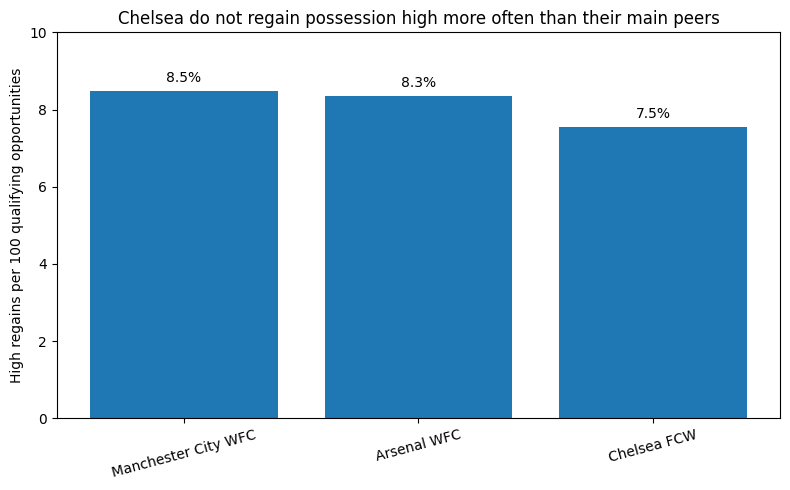

Saved: /content/drive/My Drive/02 Work & Career/00 Current Work/Independent Sports Analytics/00 Active Projects/Analytical Casework Lab/01 - Case Releases/C01 - Football Event Intelligence/outputs/figure_1_high_regain_rate.png


In [ ]:
import matplotlib.pyplot as plt

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

fig1_data = (
    sql_peer_summary[
        ["team", "high_regain_rate_pct"]
    ]
    .sort_values("high_regain_rate_pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    fig1_data["team"],
    fig1_data["high_regain_rate_pct"]
)

ax.set_title(
    "Chelsea do not regain possession high more often than their main peers"
)
ax.set_ylabel("High regains per 100 qualifying opportunities")
ax.set_xlabel("")

ax.set_ylim(0, 10)

ax.tick_params(axis="x", rotation=15)

# Add values above bars
for bar, value in zip(bars, fig1_data["high_regain_rate_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

fig.tight_layout()

FIG1_PATH = OUTPUT_DIR / "figure_1_high_regain_rate.png"
fig.savefig(FIG1_PATH, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", FIG1_PATH)

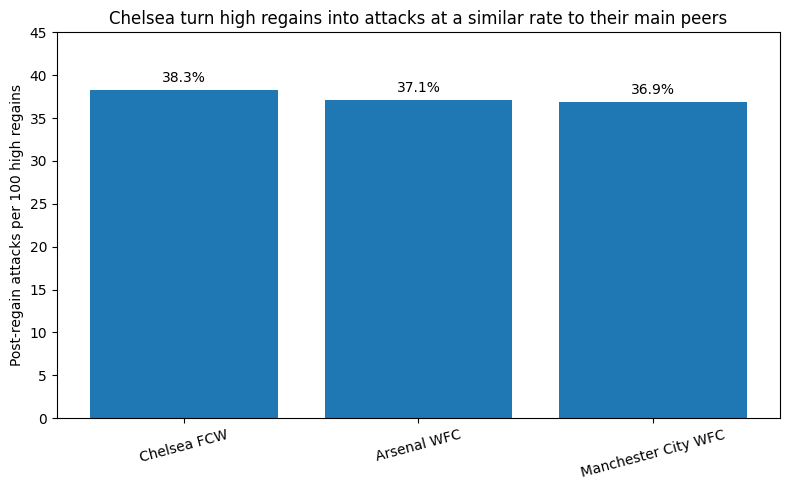

Saved: /content/drive/My Drive/02 Work & Career/00 Current Work/Independent Sports Analytics/00 Active Projects/Analytical Casework Lab/01 - Case Releases/C01 - Football Event Intelligence/outputs/figure_2_post_regain_attack_rate.png


In [ ]:
fig2_data = (
    sql_peer_summary[
        ["team", "attack_per_regain_pct"]
    ]
    .sort_values("attack_per_regain_pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    fig2_data["team"],
    fig2_data["attack_per_regain_pct"]
)

ax.set_title(
    "Chelsea turn high regains into attacks at a similar rate to their main peers"
)
ax.set_ylabel("Post-regain attacks per 100 high regains")
ax.set_xlabel("")

ax.set_ylim(0, 45)

ax.tick_params(axis="x", rotation=15)

for bar, value in zip(bars, fig2_data["attack_per_regain_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

fig.tight_layout()

FIG2_PATH = OUTPUT_DIR / "figure_2_post_regain_attack_rate.png"
fig.savefig(FIG2_PATH, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", FIG2_PATH)

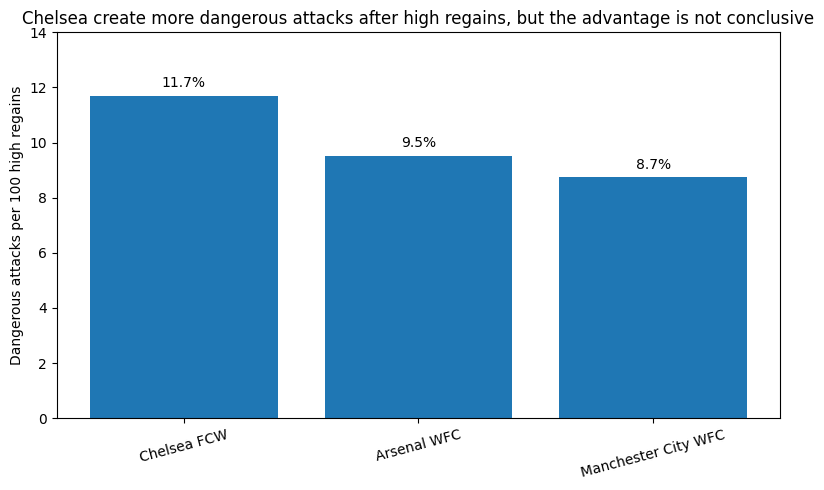

Saved: /content/drive/My Drive/02 Work & Career/00 Current Work/Independent Sports Analytics/00 Active Projects/Analytical Casework Lab/01 - Case Releases/C01 - Football Event Intelligence/outputs/figure_3_dangerous_attack_rate.png


In [138]:
fig3_data = (
    sql_peer_summary[
        ["team", "danger_per_regain_pct"]
    ]
    .sort_values("danger_per_regain_pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    fig3_data["team"],
    fig3_data["danger_per_regain_pct"]
)

ax.set_title(
    "Chelsea create more dangerous attacks after high regains, but the advantage is not conclusive"
)
ax.set_ylabel("Dangerous attacks per 100 high regains")
ax.set_xlabel("")

ax.set_ylim(0, 14)

ax.tick_params(axis="x", rotation=15)

for bar, value in zip(bars, fig3_data["danger_per_regain_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

fig.tight_layout()

FIG3_PATH = OUTPUT_DIR / "figure_3_dangerous_attack_rate.png"
fig.savefig(FIG3_PATH, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", FIG3_PATH)

## 13. Decision Summary

The evidence does **not** establish Chelsea FCW as genuinely distinctive from Manchester City WFC and Arsenal WFC across the full high-regain decision chain.

| Decision stage | Chelsea | Manchester City | Arsenal | Interpretation |
|---|---:|---:|---:|---|
| High regains per qualifying opportunity | 7.55% | 8.48% | 8.35% | Chelsea are not higher than their primary peers. |
| Post-regain attacks per high regain | 38.30% | 36.89% | 37.14% | Chelsea are only slightly higher; the difference is not convincing. |
| Dangerous attacks per high regain | 11.70% | 8.74% | 9.52% | Chelsea show the strongest descriptive rate, but the advantage is uncertain and sensitive to reasonable definition changes. |

First-pass confidence intervals and whole-match bootstrap checks do not support a meaningful Chelsea advantage. The apparent attacking advantage also changes under reasonable alternative time windows and xG thresholds.

**Coaching implication:** this analysis does not justify a major change to Chelsea's high-pressing approach. The most defensible recommendation is to maintain the current approach rather than increase pressing intensity solely on this evidence. If further analysis is undertaken, it should focus on the decisions and actions immediately after a high regain, where the most potentially useful signal appears.
